# Stage 2 MRD Sharedness Suite v2 (Jun 4)

This notebook is a second-pass Figure 3 analysis focused on the three-stage design:

1. **Shared models:** which Stage 0/1 representations transfer malignant-vs-non-malignant signal across patients?
2. **Patient-specific models:** which representations are strong in one patient or subgroup but weak as broad shared programs?
3. **Breaking apart programs:** within a prior gene space, which Stage 1 latent factors are selected by Stage 2 logistic probes, and what genes load on those factors?

The notebook is intentionally organized around decision plots rather than only reporting top global AUPRC. It should run on the current 33-representation shortlist and also on a future expanded run over all `single_geneset_only` and `single_group_only` Stage 1 combinations.

In [1]:
from __future__ import annotations

import json
import math
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'sc_classification').exists():
    REPO_ROOT = Path('/home/minhang/mds_project')

SCRIPT_DIR = REPO_ROOT / 'sc_classification' / 'scripts' / 'mrd_stage0_2' / 'stage2_supervised'
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

from stage2_sharedness_plotting import (  # noqa: E402
    infer_biological_theme,
    resolve_col,
    safe_filename,
    select_regularization_rows,
    shorten_panel_label,
)

EXPERIMENT_ID = '20260525_060508_stage0_mrd_old34_broad_screen_82db5093'
EXP_DIR = REPO_ROOT / 'sc_classification' / 'experiments' / EXPERIMENT_ID
SCORECARD_DIR = EXP_DIR / 'analysis' / 'scorecards'
MULTIOBJ_DIR = EXP_DIR / 'stage2_supervised' / 'multiobjective'
OUTPUT_DIR = EXP_DIR / 'analysis' / 'figures' / 'stage2_figure3_sharedness_v2_jun4'
TABLE_DIR = EXP_DIR / 'analysis' / 'scorecards' / 'stage2_figure3_sharedness_v2_jun4'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SELECTION_MODE = 'max_metric'
PENALTY_PRIORITY = ('elasticnet', 'l1', 'l2')
MIN_MALIGNANT_SUPPORT = 10
sns.set_theme(style='whitegrid', context='notebook')

print(EXP_DIR)
print(OUTPUT_DIR)

/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093
/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/figures/stage2_figure3_sharedness_v2_jun4


In [2]:
def read_csv(path: Path, required: bool = True) -> pd.DataFrame:
    if not path.exists():
        if required:
            raise FileNotFoundError(path)
        return pd.DataFrame()
    return pd.read_csv(path, low_memory=False)


def add_representation_id(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if out.empty or 'representation_id' in out.columns:
        return out
    needed = ['stage0_panel_id', 'representation_family', 'stage1_method', 'effective_k', 'stage1_seed']
    if not set(needed).issubset(out.columns):
        needed = ['stage0_panel_id', 'representation_family', 'stage1_method', 'requested_k', 'seed']
    if set(needed).issubset(out.columns):
        out['representation_id'] = (
            out[needed[0]].astype(str) + '|' +
            out[needed[1]].astype(str) + '|' +
            out[needed[2]].astype(str) + '|' +
            pd.to_numeric(out[needed[3]], errors='coerce').round().astype('Int64').astype(str) + '|' +
            pd.to_numeric(out[needed[4]], errors='coerce').round().astype('Int64').astype(str)
        )
    return out


def add_plot_labels(df: pd.DataFrame) -> pd.DataFrame:
    out = add_representation_id(df)
    if out.empty:
        return out
    if 'short_panel_label' not in out.columns and 'stage0_panel_id' in out.columns:
        out['short_panel_label'] = out['stage0_panel_id'].map(shorten_panel_label)
    if 'biological_theme' not in out.columns and 'stage0_panel_id' in out.columns:
        stage0_type = out['stage0_panel_type'] if 'stage0_panel_type' in out.columns else pd.Series('', index=out.index)
        out['biological_theme'] = [infer_biological_theme(p, t) for p, t in zip(out['stage0_panel_id'], stage0_type)]
    return out


def read_coefficients_for_representation(path: Path, representation_id: str) -> pd.DataFrame:
    """Read only one representation's coefficient rows from a large CSV."""
    if not path.exists():
        return pd.DataFrame()
    chunks = []
    for chunk in pd.read_csv(path, low_memory=False, chunksize=250_000):
        chunk = add_representation_id(chunk)
        sub = chunk.loc[chunk['representation_id'].astype(str).eq(str(representation_id))].copy()
        if not sub.empty:
            chunks.append(sub)
    return add_plot_labels(pd.concat(chunks, ignore_index=True)) if chunks else pd.DataFrame()


discovery_metrics = add_plot_labels(read_csv(SCORECARD_DIR / 'stage2_discovery_full_cohort_scorecard.csv'))
lopo_metrics = add_plot_labels(read_csv(SCORECARD_DIR / 'stage2_sharedness_lopo_scorecard.csv'))
lopo_by_patient = add_plot_labels(read_csv(MULTIOBJ_DIR / 'sharedness_lopo' / 'by_heldout_patient.csv'))
patient_specific_metrics = add_plot_labels(read_csv(SCORECARD_DIR / 'stage2_patient_specific_scorecard.csv'))
stage0_scorecard = add_plot_labels(read_csv(SCORECARD_DIR / 'stage0_mrd_old34_broad_scorecard.csv'))

DISCOVERY_COEF_PATH = MULTIOBJ_DIR / 'discovery_full_cohort' / 'coefficient_paths.csv'
PATIENT_SPECIFIC_COEF_PATH = MULTIOBJ_DIR / 'patient_specific' / 'coefficient_paths.csv'
LOPO_COEF_PATH = MULTIOBJ_DIR / 'sharedness_lopo' / 'coefficient_paths.csv'

for name, df in {
    'discovery_metrics': discovery_metrics,
    'lopo_metrics': lopo_metrics,
    'lopo_by_patient': lopo_by_patient,
    'patient_specific_metrics': patient_specific_metrics,
    'stage0_scorecard': stage0_scorecard,
}.items():
    print(f'{name:25s} {df.shape}')
for name, path in {
    'discovery_coef_path': DISCOVERY_COEF_PATH,
    'patient_specific_coef_path': PATIENT_SPECIFIC_COEF_PATH,
    'lopo_coef_path': LOPO_COEF_PATH,
}.items():
    print(f'{name:25s} exists={path.exists()} size_gb={(path.stat().st_size / 1e9 if path.exists() else 0):.2f}')

discovery_metrics         (41795, 78)
lopo_metrics              (41795, 79)
lopo_by_patient           (543335, 70)
patient_specific_metrics  (376155, 72)
stage0_scorecard          (755, 46)
discovery_coef_path       exists=True size_gb=0.26
patient_specific_coef_path exists=True size_gb=2.27
lopo_coef_path            exists=True size_gb=4.75


## A. Decision Table: Discovery, Sharedness, Patient-Specificity

This table is the backbone for the v2 plots. It selects one regularization setting per representation for discovery and aggregate LOPO, then summarizes the best and median patient-specific fits. The resulting quadrants are decision categories, not final biological claims.

In [3]:
def metric_col(df: pd.DataFrame, candidates: list[str]) -> str:
    return resolve_col(df, candidates, required=True)


def first_existing(df: pd.DataFrame, cols: list[str]) -> list[str]:
    return [c for c in cols if c in df.columns]


discovery_selected = select_regularization_rows(
    discovery_metrics,
    group_cols=['representation_id'],
    metric_col='stage2_auprc',
    mode=SELECTION_MODE,
    penalty_priority=PENALTY_PRIORITY,
    min_nonzero=1,
)

lopo_selected = select_regularization_rows(
    lopo_metrics,
    group_cols=['representation_id'],
    metric_col='cell_weighted_auprc',
    mode=SELECTION_MODE,
    penalty_priority=PENALTY_PRIORITY,
    min_nonzero=1,
)

patient_selected = select_regularization_rows(
    patient_specific_metrics,
    group_cols=['representation_id', 'patient_id'],
    metric_col='stage2_auprc',
    mode=SELECTION_MODE,
    penalty_priority=PENALTY_PRIORITY,
    min_nonzero=1,
)

patient_summary = (
    patient_selected.groupby('representation_id', dropna=False)
    .agg(
        max_patient_auprc=('selected_metric_value', 'max'),
        median_patient_auprc=('selected_metric_value', 'median'),
        n_patient_specific=('patient_id', 'nunique'),
    )
    .reset_index()
)

left_cols = first_existing(discovery_selected, [
    'representation_id', 'stage0_panel_id', 'stage0_panel_type', 'short_panel_label',
    'biological_theme', 'stage1_method', 'effective_k', 'stage1_seed', 'penalty', 'C',
    'l1_ratio', 'selected_metric_value', 'nonzero_coefficient_count', 'stage1_scores_path',
    'stage1_metadata_path', 'gene_list_path'
])
right_cols = first_existing(lopo_selected, [
    'representation_id', 'penalty', 'C', 'l1_ratio', 'selected_metric_value',
    'nonzero_coefficient_count', 'patient_equal_auprc', 'cell_weighted_auprc'
])

decision = discovery_selected[left_cols].rename(columns={
    'penalty': 'discovery_penalty',
    'C': 'discovery_C',
    'l1_ratio': 'discovery_l1_ratio',
    'selected_metric_value': 'discovery_auprc',
    'nonzero_coefficient_count': 'discovery_nonzero',
})
decision = decision.merge(
    lopo_selected[right_cols].rename(columns={
        'penalty': 'lopo_penalty',
        'C': 'lopo_C',
        'l1_ratio': 'lopo_l1_ratio',
        'selected_metric_value': 'lopo_auprc',
        'nonzero_coefficient_count': 'lopo_nonzero',
    }),
    on='representation_id',
    how='left',
)
decision = decision.merge(patient_summary, on='representation_id', how='left')
decision['discovery_minus_lopo'] = decision['discovery_auprc'] - decision['lopo_auprc']
decision['patient_specific_gap'] = decision['max_patient_auprc'] - decision['lopo_auprc']

discovery_med = decision['discovery_auprc'].median()
lopo_med = decision['lopo_auprc'].median()
decision['decision_quadrant'] = np.select(
    [
        decision['discovery_auprc'].ge(discovery_med) & decision['lopo_auprc'].ge(lopo_med),
        decision['discovery_auprc'].ge(discovery_med) & decision['lopo_auprc'].lt(lopo_med),
        decision['discovery_auprc'].lt(discovery_med) & decision['lopo_auprc'].ge(lopo_med),
    ],
    ['shared_candidate', 'cohort_apparent_not_shared', 'heldout_transfer_surprise'],
    default='weak_or_unresolved',
)

decision_path = TABLE_DIR / 'v2_decision_table_discovery_lopo_patient_specific.csv'
decision.to_csv(decision_path, index=False)
print(f'Wrote {decision_path} with {len(decision)} rows')
display(decision.sort_values(['lopo_auprc', 'discovery_auprc'], ascending=False).head(12))

Wrote /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness_v2_jun4/v2_decision_table_discovery_lopo_patient_specific.csv with 643 rows


,representation_id,stage0_panel_id,stage0_panel_type,short_panel_label,biological_theme,stage1_method,effective_k,stage1_seed,discovery_penalty,discovery_C,...,lopo_l1_ratio,lopo_auprc,patient_equal_auprc,cell_weighted_auprc,max_patient_auprc,median_patient_auprc,n_patient_specific,discovery_minus_lopo,patient_specific_gap,decision_quadrant
589,single_group__innate_immune_context|dr|fa|40|42,single_group__innate_immune_context,single_group_only,innate immune context,inflammatory_immune,fa,40,42,l2,0.000100,...,0.9,0.477428,0.214930,0.477428,1.000000,0.746788,9,0.134373,0.522572,shared_candidate
601,single_group__proliferation_metabolism|dr|fact...,single_group__proliferation_metabolism,single_group_only,proliferation metabolism,metabolism,factosig,40,42,l2,0.000100,...,NaN,0.385209,0.248704,0.385209,1.000000,0.804418,9,0.189271,0.614791,shared_candidate
588,single_group__innate_immune_context|dr|fa|20|42,single_group__innate_immune_context,single_group_only,innate immune context,inflammatory_immune,fa,20,42,l1,0.002154,...,NaN,0.382140,0.201533,0.382140,0.976920,0.173537,9,0.096601,0.594780,shared_candidate
609,single_group__proliferation_metabolism|dr|pca|...,single_group__proliferation_metabolism,single_group_only,proliferation metabolism,metabolism,pca,40,42,l2,0.000100,...,NaN,0.359437,0.245479,0.359437,1.000000,0.703377,9,0.173814,0.640563,shared_candidate
177,single_geneset__hallmark_inflammatory_response...,single_geneset__hallmark_inflammatory_response,single_geneset_only,inflammatory response,inflammatory_immune,factosig_promax,20,42,elasticnet,0.002154,...,NaN,0.350858,0.223893,0.350858,0.983331,0.084931,9,0.165922,0.632473,shared_candidate
181,single_geneset__hallmark_inflammatory_response...,single_geneset__hallmark_inflammatory_response,single_geneset_only,inflammatory response,inflammatory_immune,factosig,20,42,l2,0.000100,...,0.1,0.348707,0.222110,0.348707,0.983334,0.149076,9,0.167922,0.634628,shared_candidate
185,single_geneset__hallmark_inflammatory_response...,single_geneset__hallmark_inflammatory_response,single_geneset_only,inflammatory response,inflammatory_immune,fa,20,42,l2,0.000100,...,0.1,0.333985,0.217176,0.333985,0.975673,0.186001,9,0.152641,0.641688,shared_candidate
584,single_group__innate_immune_context|dr|factosi...,single_group__innate_immune_context,single_group_only,innate immune context,inflammatory_immune,factosig,20,42,l2,0.000100,...,0.1,0.313805,0.195106,0.313805,0.988781,0.215662,9,0.207521,0.674976,shared_candidate
580,single_group__innate_immune_context|dr|factosi...,single_group__innate_immune_context,single_group_only,innate immune context,inflammatory_immune,factosig_promax,20,42,l1,0.010000,...,0.5,0.310712,0.203213,0.310712,0.988744,0.248088,9,0.209464,0.678032,shared_candidate
597,single_group__proliferation_metabolism|dr|fact...,single_group__proliferation_metabolism,single_group_only,proliferation metabolism,metabolism,factosig_promax,40,42,elasticnet,4.641589,...,NaN,0.300884,0.246203,0.300884,1.000000,0.804121,9,0.264980,0.699116,shared_candidate


/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/figures/stage2_figure3_sharedness_v2_jun4/v2A_discovery_vs_lopo_decision_map.png


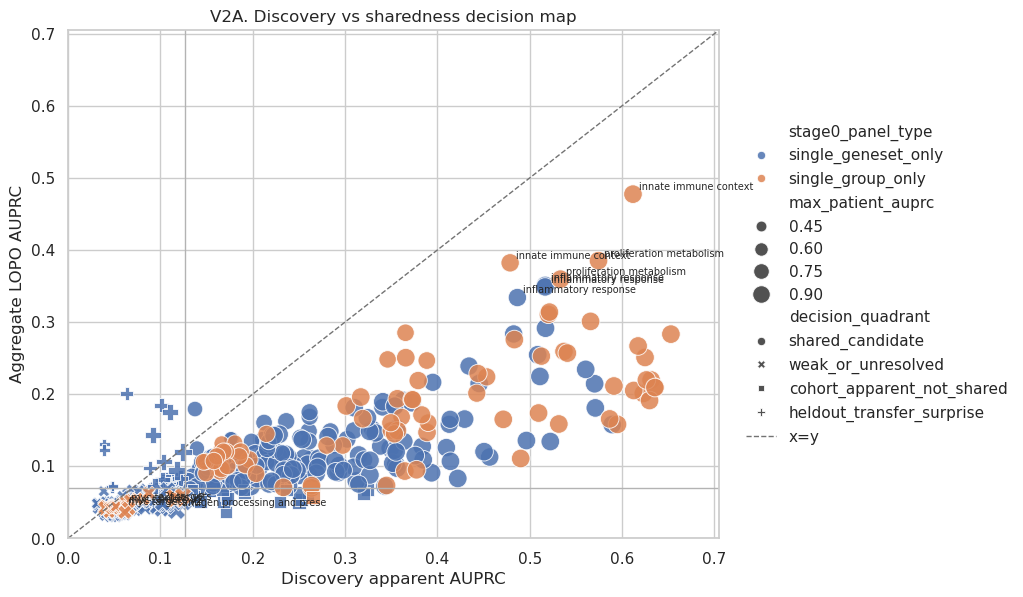

In [4]:
def savefig(fig: plt.Figure, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=220, bbox_inches='tight')
    fig.savefig(path.with_suffix('.pdf'), bbox_inches='tight')
    print(path)


def annotate_top(ax, df: pd.DataFrame, score_col: str, n: int = 8, x='discovery_auprc', y='lopo_auprc'):
    top = df.sort_values(score_col, ascending=False).head(n)
    for _, row in top.iterrows():
        ax.text(row[x] + 0.006, row[y] + 0.006, str(row.get('short_panel_label', row['stage0_panel_id']))[:28], fontsize=7)


fig, ax = plt.subplots(figsize=(8.4, 6.6))
plot_df = decision.dropna(subset=['discovery_auprc', 'lopo_auprc']).copy()
sns.scatterplot(
    data=plot_df,
    x='discovery_auprc',
    y='lopo_auprc',
    hue='stage0_panel_type',
    style='decision_quadrant',
    size='max_patient_auprc',
    sizes=(40, 180),
    alpha=0.85,
    ax=ax,
)
lims = [0, max(plot_df[['discovery_auprc', 'lopo_auprc']].max().max() * 1.08, 0.1)]
ax.plot(lims, lims, color='0.45', ls='--', lw=1, label='x=y')
ax.axvline(discovery_med, color='0.7', lw=1)
ax.axhline(lopo_med, color='0.7', lw=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Discovery apparent AUPRC')
ax.set_ylabel('Aggregate LOPO AUPRC')
ax.set_title('V2A. Discovery vs sharedness decision map')
annotate_top(ax, plot_df, 'lopo_auprc', n=7)
annotate_top(ax, plot_df.assign(patient_specific_gap=plot_df['patient_specific_gap'].fillna(-np.inf)), 'patient_specific_gap', n=5)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
savefig(fig, OUTPUT_DIR / 'v2A_discovery_vs_lopo_decision_map.png')
plt.show()

## A2. Method-Aware Stage 1 Stability

This diagnostic treats each DR method as a different inductive bias and treats K as an ordered capacity curve within that method. A panel is stronger evidence for a prior gene-space claim when the signal is stable across methods or at least stable across K within one method. A single winning method/K cell is useful for follow-up, but should not be described as robust panel-level biology.

In [5]:
# Method-aware Stage 1 stability. Labels are heuristic triage tags, not biological verdicts.
CORE_STAGE1_METHODS = ['pca', 'fa', 'factosig', 'factosig_promax']
LOPO_HIGH_THRESHOLD = float(decision['lopo_auprc'].median())
K_STABLE_IQR_MAX = 0.05
K_STABLE_RANGE_MAX = 0.10

stage1_grid = decision.loc[decision['stage1_method'].isin(CORE_STAGE1_METHODS)].copy()
stage1_grid['effective_k'] = pd.to_numeric(stage1_grid['effective_k'], errors='coerce')
stage1_grid['above_lopo_median'] = stage1_grid['lopo_auprc'].ge(LOPO_HIGH_THRESHOLD)
stage1_grid['is_shared_candidate'] = stage1_grid['decision_quadrant'].eq('shared_candidate')

panel_method_k_distribution = stage1_grid[[
    'stage0_panel_id', 'short_panel_label', 'stage0_panel_type', 'biological_theme',
    'stage1_method', 'effective_k', 'stage1_seed', 'representation_id',
    'discovery_auprc', 'lopo_auprc', 'max_patient_auprc', 'patient_specific_gap',
    'decision_quadrant', 'above_lopo_median', 'is_shared_candidate'
]].sort_values(['stage0_panel_id', 'stage1_method', 'effective_k'])
panel_method_k_distribution.to_csv(TABLE_DIR / 'v2_panel_method_k_lopo_distribution.csv', index=False)


def _second_best_gap(values: pd.Series) -> float:
    vals = pd.to_numeric(values, errors='coerce').dropna().sort_values(ascending=False)
    if len(vals) < 2:
        return np.nan
    return float(vals.iloc[0] - vals.iloc[1])

panel_method_stage1_stability = (
    stage1_grid.groupby(['stage0_panel_id', 'stage1_method'], dropna=False)
    .agg(
        short_panel_label=('short_panel_label', 'first'),
        stage0_panel_type=('stage0_panel_type', 'first'),
        biological_theme=('biological_theme', 'first'),
        n_k=('effective_k', 'nunique'),
        k_values=('effective_k', lambda s: ','.join(str(int(v)) for v in sorted(pd.to_numeric(s, errors='coerce').dropna().unique()))),
        best_k=('effective_k', lambda s: int(stage1_grid.loc[s.index].sort_values('lopo_auprc', ascending=False)['effective_k'].iloc[0])),
        best_lopo_auprc=('lopo_auprc', 'max'),
        median_lopo_auprc=('lopo_auprc', 'median'),
        lopo_iqr=('lopo_auprc', lambda s: s.quantile(0.75) - s.quantile(0.25)),
        lopo_range=('lopo_auprc', lambda s: s.max() - s.min()),
        best_minus_median_lopo=('lopo_auprc', lambda s: s.max() - s.median()),
        best_vs_second_lopo_gap=('lopo_auprc', _second_best_gap),
        n_above_lopo_median=('above_lopo_median', 'sum'),
        n_shared_candidate=('is_shared_candidate', 'sum'),
        n_available_representations=('representation_id', 'nunique'),
    )
    .reset_index()
)
panel_method_stage1_stability['method_clears_lopo_threshold'] = panel_method_stage1_stability['best_lopo_auprc'].ge(LOPO_HIGH_THRESHOLD)
panel_method_stage1_stability['k_stable_within_method'] = (
    panel_method_stage1_stability['method_clears_lopo_threshold']
    & panel_method_stage1_stability['n_k'].ge(2)
    & panel_method_stage1_stability['lopo_iqr'].le(K_STABLE_IQR_MAX)
    & panel_method_stage1_stability['lopo_range'].le(K_STABLE_RANGE_MAX)
)
panel_method_stage1_stability.to_csv(TABLE_DIR / 'v2_panel_method_stage1_stability_summary.csv', index=False)


def label_panel_stage1(group: pd.DataFrame) -> str:
    n_working_methods = int(group['method_clears_lopo_threshold'].sum())
    n_stable_working_methods = int(group['k_stable_within_method'].sum())
    n_above = int(group['n_above_lopo_median'].sum())
    if n_working_methods == 0:
        return 'null'
    if n_above <= 1:
        return 'single_spike_brittle'
    if n_working_methods >= 2 and n_stable_working_methods >= 1:
        return 'method_robust'
    if n_working_methods == 1 and n_stable_working_methods == 1:
        return 'method_specific_k_stable'
    return 'k_sensitive'

panel_stage1_stability_summary = (
    panel_method_stage1_stability.groupby('stage0_panel_id', dropna=False)
    .agg(
        short_panel_label=('short_panel_label', 'first'),
        stage0_panel_type=('stage0_panel_type', 'first'),
        biological_theme=('biological_theme', 'first'),
        n_methods_available=('stage1_method', 'nunique'),
        n_working_methods=('method_clears_lopo_threshold', 'sum'),
        n_k_stable_working_methods=('k_stable_within_method', 'sum'),
        n_above_lopo_median_combos=('n_above_lopo_median', 'sum'),
        n_shared_candidate_combos=('n_shared_candidate', 'sum'),
        panel_lopo_iqr=('median_lopo_auprc', lambda s: s.quantile(0.75) - s.quantile(0.25)),
        best_method_lopo_auprc=('best_lopo_auprc', 'max'),
        median_method_lopo_auprc=('median_lopo_auprc', 'median'),
    )
    .reset_index()
)
label_map = panel_method_stage1_stability.groupby('stage0_panel_id', dropna=False).apply(label_panel_stage1)
panel_stage1_stability_summary = panel_stage1_stability_summary.merge(
    label_map.rename('method_stability_label').reset_index(),
    on='stage0_panel_id',
    how='left',
)
best_method = (
    panel_method_stage1_stability.sort_values('best_lopo_auprc', ascending=False)
    .drop_duplicates('stage0_panel_id')
    [['stage0_panel_id', 'stage1_method', 'best_k', 'best_lopo_auprc', 'lopo_iqr', 'lopo_range']]
    .rename(columns={
        'stage1_method': 'best_lopo_stage1_method',
        'best_k': 'best_lopo_effective_k',
        'best_lopo_auprc': 'best_method_lopo_auprc_check',
        'lopo_iqr': 'best_method_lopo_iqr_across_k',
        'lopo_range': 'best_method_lopo_range_across_k',
    })
)
panel_stage1_stability_summary = panel_stage1_stability_summary.merge(best_method, on='stage0_panel_id', how='left')
panel_stage1_stability_summary.to_csv(TABLE_DIR / 'v2_panel_stage1_stability_summary.csv', index=False)

print('LOPO high threshold for stability labels:', LOPO_HIGH_THRESHOLD)
print('Wrote method-aware Stage 1 stability summaries:')
print(' -', TABLE_DIR / 'v2_panel_method_k_lopo_distribution.csv')
print(' -', TABLE_DIR / 'v2_panel_method_stage1_stability_summary.csv')
print(' -', TABLE_DIR / 'v2_panel_stage1_stability_summary.csv')
display(panel_stage1_stability_summary.sort_values(['method_stability_label', 'best_method_lopo_auprc'], ascending=[True, False]).head(20))

LOPO high threshold for stability labels: 0.0693851735060485
Wrote method-aware Stage 1 stability summaries:
 - /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness_v2_jun4/v2_panel_method_k_lopo_distribution.csv
 - /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness_v2_jun4/v2_panel_method_stage1_stability_summary.csv
 - /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness_v2_jun4/v2_panel_stage1_stability_summary.csv


/tmp/ipykernel_1425153/1543040133.py:89: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  label_map = panel_method_stage1_stability.groupby('stage0_panel_id', dropna=False).apply(label_panel_stage1)


,stage0_panel_id,short_panel_label,stage0_panel_type,biological_theme,n_methods_available,n_working_methods,n_k_stable_working_methods,n_above_lopo_median_combos,n_shared_candidate_combos,panel_lopo_iqr,best_method_lopo_auprc,median_method_lopo_auprc,method_stability_label,best_lopo_stage1_method,best_lopo_effective_k,best_method_lopo_auprc_check,best_method_lopo_iqr_across_k,best_method_lopo_range_across_k
37,single_group__innate_immune_context,innate immune context,single_group_only,inflammatory_immune,4,4,0,12,12,0.044608,0.477428,0.242824,k_sensitive,fa,40,0.477428,0.181425,0.434648
38,single_group__proliferation_metabolism,proliferation metabolism,single_group_only,metabolism,4,4,0,12,12,0.019138,0.385209,0.151392,k_sensitive,factosig,40,0.385209,0.195054,0.348440
11,single_geneset__hallmark_inflammatory_response,inflammatory response,single_geneset_only,inflammatory_immune,4,4,0,12,12,0.015638,0.350858,0.185281,k_sensitive,factosig_promax,20,0.350858,0.172435,0.308861
27,single_geneset__reactome_cytokine_signaling_in...,cytokine signaling in immune system,single_geneset_only,cytokine_jak_stat,4,4,0,12,12,0.025271,0.283453,0.153389,k_sensitive,fa,20,0.283453,0.088108,0.240145
36,single_group__inflammatory_interferon,inflammatory interferon,single_group_only,interferon,4,4,0,12,12,0.010181,0.283202,0.149253,k_sensitive,fa,40,0.283202,0.177844,0.241402
35,single_group__cytokine_jak_stat,cytokine jak stat,single_group_only,cytokine_jak_stat,4,4,0,12,12,0.021933,0.250877,0.134851,k_sensitive,fa,40,0.250877,0.081596,0.206741
39,single_group__stress_arrest,stress arrest,single_group_only,hypoxia_stress,4,4,0,12,12,0.008817,0.209094,0.137650,k_sensitive,factosig,40,0.209094,0.093465,0.155573
24,single_geneset__kegg_jak_stat_signaling_pathway,jak stat signaling pathway,single_geneset_only,cytokine_jak_stat,4,4,0,12,12,0.056122,0.189407,0.149661,k_sensitive,factosig_promax,40,0.189407,0.043939,0.136045
12,single_geneset__hallmark_interferon_alpha_resp...,interferon alpha response,single_geneset_only,interferon,4,4,2,8,2,0.033704,0.200924,0.090436,method_robust,fa,10,0.200924,0.078759,0.135680
0,single_geneset__hallmark_allograft_rejection,allograft rejection,single_geneset_only,antigen_presentation_mhc,4,4,2,12,12,0.013411,0.191563,0.131879,method_robust,pca,20,0.191563,0.060521,0.149565


## B. Per-Patient LOPO: Raw AUPRC (superseded by the lift view)

Raw AUPRC is hard to compare across patients because malignant prevalence differs sharply: on a fixed 0-1 scale the heatmap essentially re-draws the prevalence table (high-prevalence P02/P03/P04 look bright, low-prevalence P01/P06/P09 look dark regardless of model quality). The prevalence-corrected view lives in **V2F4** (held-out lift over prevalence). V2B1 is kept only as a raw-numbers reference; the enrichment ratio (AUPRC / prevalence) was removed because it explodes for low-prevalence patients and is not interpretable.

In [6]:
lopo_patient_best = select_regularization_rows(
    lopo_by_patient,
    group_cols=['representation_id', 'heldout_patient_id'],
    metric_col='stage2_auprc',
    mode=SELECTION_MODE,
    penalty_priority=PENALTY_PRIORITY,
    min_nonzero=1,
)

mal_col = resolve_col(lopo_patient_best, ['n_test_malignant', 'n_malignant'], required=False)
norm_col = resolve_col(lopo_patient_best, ['n_test_non_malignant', 'n_normal'], required=False)
if mal_col and norm_col:
    malignant = pd.to_numeric(lopo_patient_best[mal_col], errors='coerce')
    normal = pd.to_numeric(lopo_patient_best[norm_col], errors='coerce')
    lopo_patient_best['malignant_prevalence'] = malignant / (malignant + normal).replace(0, np.nan)
    lopo_patient_best['normal_only'] = malignant.fillna(0).eq(0) & normal.fillna(0).gt(0)
    lopo_patient_best['low_malignant_support'] = malignant.gt(0) & malignant.lt(MIN_MALIGNANT_SUPPORT)
else:
    lopo_patient_best['malignant_prevalence'] = np.nan
    lopo_patient_best['normal_only'] = False
    lopo_patient_best['low_malignant_support'] = False

lopo_patient_best['heldout_auprc'] = pd.to_numeric(lopo_patient_best['selected_metric_value'], errors='coerce')
lopo_patient_best = lopo_patient_best.merge(
    decision[['representation_id', 'lopo_auprc', 'discovery_auprc', 'short_panel_label', 'stage0_panel_type', 'biological_theme']],
    on='representation_id',
    how='left',
    suffixes=('', '_decision'),
)
lopo_patient_best['heatmap_label'] = lopo_patient_best['short_panel_label'].fillna(lopo_patient_best['stage0_panel_id'].map(shorten_panel_label))

# Select rows that show either shared performance or patient-specific peaks.
supported = lopo_patient_best.loc[~lopo_patient_best['normal_only'] & ~lopo_patient_best['low_malignant_support']].copy()
peak_by_rep = supported.groupby('representation_id').agg(
    max_heldout_auprc=('heldout_auprc', 'max'),
    mean_heldout_auprc=('heldout_auprc', 'mean'),
).reset_index()
heatmap_reps = set(decision.sort_values('lopo_auprc', ascending=False).head(18)['representation_id'])
heatmap_reps |= set(peak_by_rep.sort_values('max_heldout_auprc', ascending=False).head(18)['representation_id'])
# Force examples discussed in chat if present.
for pattern in ['il2_stat5', 'stress_arrest', 'interferon', 'antigen', 'cytokine']:
    heatmap_reps |= set(decision.loc[decision['stage0_panel_id'].astype(str).str.contains(pattern, case=False, na=False), 'representation_id'])

heat = lopo_patient_best.loc[lopo_patient_best['representation_id'].isin(heatmap_reps)].copy()
heat.to_csv(TABLE_DIR / 'v2_lopo_patient_best_regularization_long.csv', index=False)
print('heatmap representations', heat['representation_id'].nunique(), 'rows', len(heat))
display(peak_by_rep.sort_values('max_heldout_auprc', ascending=False).head(12))

heatmap representations 242 rows 3146


,representation_id,max_heldout_auprc,mean_heldout_auprc
589,single_group__innate_immune_context|dr|fa|40|42,0.939683,0.296730
177,single_geneset__hallmark_inflammatory_response...,0.919792,0.291294
181,single_geneset__hallmark_inflammatory_response...,0.917308,0.289785
185,single_geneset__hallmark_inflammatory_response...,0.902173,0.282837
579,single_group__innate_immune_context|dr|factosi...,0.900715,0.296244
186,single_geneset__hallmark_inflammatory_response...,0.899772,0.277375
613,single_group__stress_arrest|dr|factosig_promax...,0.898822,0.335003
583,single_group__innate_immune_context|dr|factosi...,0.893788,0.293756
612,single_group__stress_arrest|dr|factosig_promax...,0.877416,0.335097
580,single_group__innate_immune_context|dr|factosi...,0.874778,0.303386


/tmp/ipykernel_1425153/3132742123.py:22: PerformanceWarning: indexing past lexsort depth may impact performance.
  if (row_label, patient) in support.index:
/tmp/ipykernel_1425153/3132742123.py:23: PerformanceWarning: indexing past lexsort depth may impact performance.
  rec = support.loc[(row_label, patient)]


/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/figures/stage2_figure3_sharedness_v2_jun4/v2B1_lopo_patient_best_auprc_heatmap.png


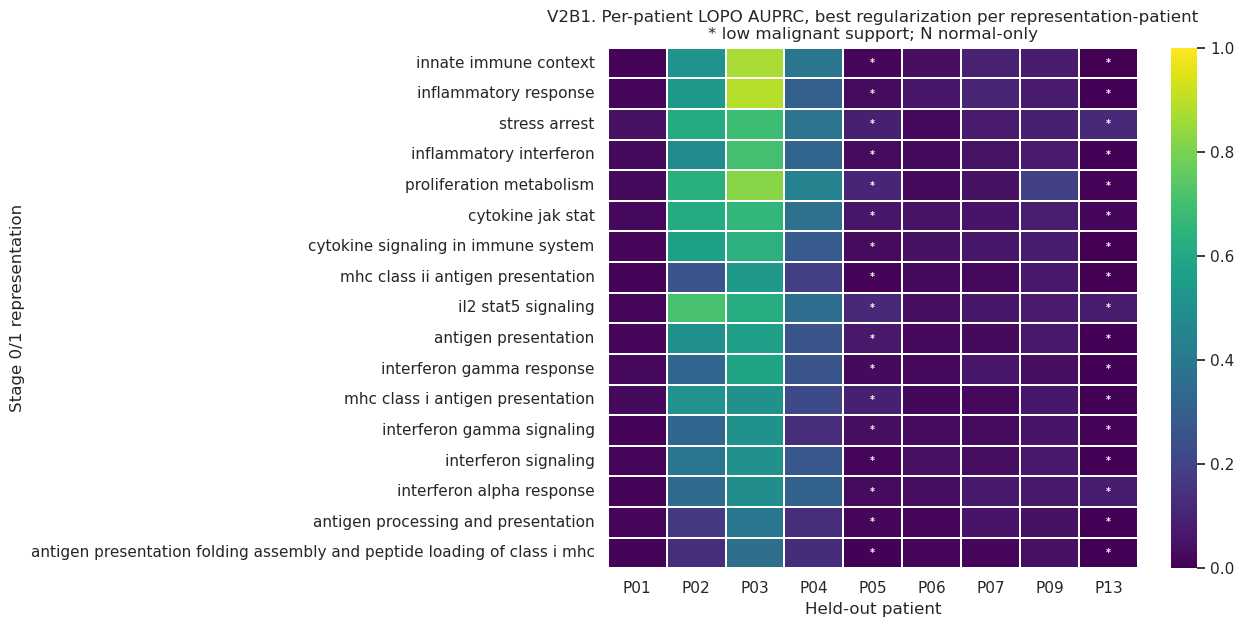

In [7]:
def clustered_matrix(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    mat = df.pivot_table(index='heatmap_label', columns='heldout_patient_id', values=value_col, aggfunc='mean')
    order = (
        df.groupby('heatmap_label')['heldout_auprc']
        .max()
        .sort_values(ascending=False)
        .index
    )
    return mat.reindex(order)


def plot_patient_heatmap(df: pd.DataFrame, value_col: str, title: str, cmap: str, vmax: float | None, path: Path):
    mat = clustered_matrix(df, value_col)
    fig_h = max(5, min(18, 0.28 * len(mat) + 2.0))
    fig_w = max(7, min(15, 0.45 * len(mat.columns) + 4.5))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(mat, cmap=cmap, vmin=0, vmax=vmax, linewidths=0.25, linecolor='white', ax=ax)
    support = df.set_index(['heatmap_label', 'heldout_patient_id'])
    for y, row_label in enumerate(mat.index):
        for x, patient in enumerate(mat.columns):
            mark = ''
            if (row_label, patient) in support.index:
                rec = support.loc[(row_label, patient)]
                if isinstance(rec, pd.DataFrame):
                    rec = rec.iloc[0]
                if bool(rec.get('normal_only', False)):
                    mark = 'N'
                elif bool(rec.get('low_malignant_support', False)):
                    mark = '*'
            if mark:
                ax.text(x + 0.5, y + 0.5, mark, ha='center', va='center', color='white', fontsize=7, fontweight='bold')
    ax.set_xlabel('Held-out patient')
    ax.set_ylabel('Stage 0/1 representation')
    ax.set_title(title + '\n* low malignant support; N normal-only')
    savefig(fig, path)
    plt.show()
    return mat

raw_matrix = plot_patient_heatmap(
    heat,
    'heldout_auprc',
    'V2B1. Per-patient LOPO AUPRC, best regularization per representation-patient',
    cmap='viridis',
    vmax=1.0,
    path=OUTPUT_DIR / 'v2B1_lopo_patient_best_auprc_heatmap.png',
)
raw_matrix.to_csv(TABLE_DIR / 'v2B1_lopo_patient_best_auprc_matrix.csv')

## B2. Panel-Level Patient Transfer Topology

The heatmaps above are useful for exploratory inspection, but they average over a selected representation subset and can overemphasize patient-level prevalence/support artifacts. This panel-level table instead asks, for each panel and optionally each DR method, how often the best aggregate-LOPO representation beats the held-out patient's own malignant-prevalence baseline.

For each held-out patient:

```text
malignant_prevalence = n_malignant / (n_malignant + n_non_malignant)
heldout_lift = heldout_AUPRC - malignant_prevalence
```

Positive lift means the model ranks malignant cells better than a random ranking for that patient. Raw AUPRC, lift, and support flags should be interpreted together.

In [8]:
# Panel-level patient-transfer topology using the best aggregate-LOPO representation per panel/method.
transfer = lopo_patient_best.copy()
transfer['heldout_lift'] = transfer['heldout_auprc'] - transfer['malignant_prevalence']
transfer.loc[~np.isfinite(transfer['heldout_lift']), 'heldout_lift'] = np.nan
normal_only = transfer['normal_only'].astype('boolean').fillna(False)
low_malignant_support = transfer['low_malignant_support'].astype('boolean').fillna(False)
transfer['supported_patient'] = (
    ~normal_only
    & ~low_malignant_support
    & transfer['heldout_lift'].notna()
)
transfer['positive_lift'] = transfer['supported_patient'] & transfer['heldout_lift'].gt(0)

# Select the best aggregate-LOPO representation at two granularities:
# panel-only and panel x method. These are the rows whose per-patient transfer vectors we summarize.
panel_best_reps = (
    decision.sort_values('lopo_auprc', ascending=False)
    .drop_duplicates('stage0_panel_id')
    [[
        'stage0_panel_id', 'representation_id', 'short_panel_label', 'stage0_panel_type',
        'biological_theme', 'stage1_method', 'effective_k', 'stage1_seed', 'lopo_auprc',
        'discovery_auprc', 'decision_quadrant', 'max_patient_auprc', 'patient_specific_gap'
    ]]
    .rename(columns={
        'representation_id': 'selected_representation_id',
        'stage1_method': 'selected_stage1_method',
        'effective_k': 'selected_effective_k',
        'stage1_seed': 'selected_stage1_seed',
        'lopo_auprc': 'aggregate_lopo_auprc',
        'discovery_auprc': 'selected_discovery_auprc',
        'decision_quadrant': 'selected_decision_quadrant',
    })
)

panel_method_best_reps = (
    decision.loc[~decision['stage1_method'].eq('direct_gene')]
    .sort_values('lopo_auprc', ascending=False)
    .drop_duplicates(['stage0_panel_id', 'stage1_method'])
    [[
        'stage0_panel_id', 'stage1_method', 'representation_id', 'short_panel_label',
        'stage0_panel_type', 'biological_theme', 'effective_k', 'stage1_seed', 'lopo_auprc',
        'discovery_auprc', 'decision_quadrant', 'max_patient_auprc', 'patient_specific_gap'
    ]]
    .rename(columns={
        'representation_id': 'selected_representation_id',
        'stage1_method': 'selected_stage1_method',
        'effective_k': 'selected_effective_k',
        'stage1_seed': 'selected_stage1_seed',
        'lopo_auprc': 'aggregate_lopo_auprc',
        'discovery_auprc': 'selected_discovery_auprc',
        'decision_quadrant': 'selected_decision_quadrant',
    })
)

transfer_cols = [
    'representation_id', 'heldout_patient_id', 'heldout_auprc', 'malignant_prevalence',
    'heldout_lift', 'normal_only', 'low_malignant_support',
    'supported_patient', 'positive_lift'
]

def attach_transfer(selected: pd.DataFrame, scope: str) -> pd.DataFrame:
    out = selected.merge(
        transfer[transfer_cols],
        left_on='selected_representation_id',
        right_on='representation_id',
        how='left',
    ).drop(columns=['representation_id'])
    out.insert(0, 'summary_scope', scope)
    return out

panel_transfer_long = attach_transfer(panel_best_reps, 'panel_best_lopo')
panel_method_transfer_long = attach_transfer(panel_method_best_reps, 'panel_method_best_lopo')
transfer_long = pd.concat([panel_transfer_long, panel_method_transfer_long], ignore_index=True)
transfer_long.to_csv(TABLE_DIR / 'v2_panel_lopo_patient_transfer_long.csv', index=False)


def summarize_transfer(group: pd.DataFrame) -> pd.Series:
    supported_mask = group['supported_patient'].astype('boolean').fillna(False)
    supported = group.loc[supported_mask].copy()
    if supported.empty:
        return pd.Series({
            'n_heldout_patients': group['heldout_patient_id'].nunique(),
            'n_supported_patients': 0,
            'n_positive_lift_patients': 0,
            'frac_positive_lift_patients': np.nan,
            'median_heldout_auprc': np.nan,
            'median_heldout_lift': np.nan,
            'p20_heldout_lift': np.nan,
            'worst_supported_patient_id': np.nan,
            'worst_supported_patient_lift': np.nan,
            'best_supported_patient_id': np.nan,
            'best_supported_patient_lift': np.nan,
        })
    lifts = pd.to_numeric(supported['heldout_lift'], errors='coerce')
    worst_idx = lifts.idxmin()
    best_idx = lifts.idxmax()
    return pd.Series({
        'n_heldout_patients': group['heldout_patient_id'].nunique(),
        'n_supported_patients': supported['heldout_patient_id'].nunique(),
        'n_positive_lift_patients': int(supported['positive_lift'].sum()),
        'frac_positive_lift_patients': float(supported['positive_lift'].mean()),
        'median_heldout_auprc': supported['heldout_auprc'].median(),
        'median_heldout_lift': lifts.median(),
        'p20_heldout_lift': lifts.quantile(0.20),
        'worst_supported_patient_id': supported.loc[worst_idx, 'heldout_patient_id'],
        'worst_supported_patient_lift': lifts.loc[worst_idx],
        'best_supported_patient_id': supported.loc[best_idx, 'heldout_patient_id'],
        'best_supported_patient_lift': lifts.loc[best_idx],
    })

id_cols = [
    'summary_scope', 'stage0_panel_id', 'short_panel_label', 'stage0_panel_type', 'biological_theme',
    'selected_representation_id', 'selected_stage1_method', 'selected_effective_k',
    'aggregate_lopo_auprc', 'selected_discovery_auprc', 'selected_decision_quadrant',
    'max_patient_auprc', 'patient_specific_gap'
]
panel_patient_summary = (
    panel_transfer_long.groupby(id_cols, dropna=False)
    .apply(summarize_transfer)
    .reset_index()
    .sort_values(['median_heldout_lift', 'p20_heldout_lift'], ascending=False)
)
panel_method_patient_summary = (
    panel_method_transfer_long.groupby(id_cols, dropna=False)
    .apply(summarize_transfer)
    .reset_index()
    .sort_values(['stage0_panel_id', 'selected_stage1_method'])
)
panel_patient_summary.to_csv(TABLE_DIR / 'v2_panel_lopo_patient_summary.csv', index=False)
panel_method_patient_summary.to_csv(TABLE_DIR / 'v2_panel_method_lopo_patient_summary.csv', index=False)

# Patient leverage: change in median supported-patient lift when a patient is removed.
leverage_records = []
for keys, group in panel_method_transfer_long.groupby(id_cols, dropna=False):
    supported_mask = group['supported_patient'].astype('boolean').fillna(False)
    supported = group.loc[supported_mask].copy()
    if len(supported) < 3:
        continue
    full_median = supported['heldout_lift'].median()
    key_record = dict(zip(id_cols, keys if isinstance(keys, tuple) else (keys,)))
    for patient, sub in supported.groupby('heldout_patient_id'):
        dropped = supported.loc[~supported['heldout_patient_id'].eq(patient)]
        loo_median = dropped['heldout_lift'].median() if not dropped.empty else np.nan
        leverage_records.append({
            **key_record,
            'dropped_patient_id': patient,
            'full_median_heldout_lift': full_median,
            'leave_one_patient_out_median_lift': loo_median,
            'patient_leverage_delta': full_median - loo_median,
            'patient_leverage_abs_delta': abs(full_median - loo_median) if pd.notna(loo_median) else np.nan,
        })
patient_leverage = pd.DataFrame(leverage_records).sort_values('patient_leverage_abs_delta', ascending=False)
patient_leverage.to_csv(TABLE_DIR / 'v2_patient_leverage_on_panel_method_median_lift.csv', index=False)

print('Wrote panel transfer summaries:')
print(' -', TABLE_DIR / 'v2_panel_lopo_patient_transfer_long.csv')
print(' -', TABLE_DIR / 'v2_panel_lopo_patient_summary.csv')
print(' -', TABLE_DIR / 'v2_panel_method_lopo_patient_summary.csv')
print(' -', TABLE_DIR / 'v2_patient_leverage_on_panel_method_median_lift.csv')
display(panel_patient_summary.head(15))

/tmp/ipykernel_1425153/384716283.py:119: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_transfer)


/tmp/ipykernel_1425153/384716283.py:125: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_transfer)


Wrote panel transfer summaries:
 - /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness_v2_jun4/v2_panel_lopo_patient_transfer_long.csv
 - /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness_v2_jun4/v2_panel_lopo_patient_summary.csv
 - /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness_v2_jun4/v2_panel_method_lopo_patient_summary.csv
 - /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/scorecards/stage2_figure3_sharedness_v2_jun4/v2_patient_leverage_on_panel_method_median_lift.csv


,summary_scope,stage0_panel_id,short_panel_label,stage0_panel_type,biological_theme,selected_representation_id,selected_stage1_method,selected_effective_k,aggregate_lopo_auprc,selected_discovery_auprc,...,n_supported_patients,n_positive_lift_patients,frac_positive_lift_patients,median_heldout_auprc,median_heldout_lift,p20_heldout_lift,worst_supported_patient_id,worst_supported_patient_lift,best_supported_patient_id,best_supported_patient_lift
38,panel_best_lopo,single_group__proliferation_metabolism,proliferation metabolism,single_group_only,metabolism,single_group__proliferation_metabolism|dr|fact...,factosig,40,0.385209,0.574480,...,7,7,1.0,0.193224,0.171328,0.023144,P06,0.008158,P03,0.531206
21,panel_best_lopo,single_geneset__hallmark_tnfa_signaling_via_nfkb,tnfa signaling via nfkb,single_geneset_only,nfkb_tnf,single_geneset__hallmark_tnfa_signaling_via_nf...,factosig,20,0.167176,0.324174,...,7,7,1.0,0.191609,0.169712,0.020382,P01,0.006852,P03,0.498830
6,panel_best_lopo,single_geneset__hallmark_g2m_checkpoint,g2m checkpoint,single_geneset_only,cell_cycle,single_geneset__hallmark_g2m_checkpoint|dr|pca...,pca,40,0.117113,0.202502,...,7,7,1.0,0.191341,0.169304,0.015521,P01,0.009058,P04,0.277064
39,panel_best_lopo,single_group__stress_arrest,stress arrest,single_group_only,hypoxia_stress,single_group__stress_arrest|dr|factosig|40|42,factosig,40,0.209094,0.635584,...,7,7,1.0,0.139543,0.129474,0.048499,P06,0.016647,P02,0.532114
40,panel_best_lopo,single_group__tgf_plasticity,tgf plasticity,single_group_only,other,single_group__tgf_plasticity|dr|factosig|40|42,factosig,40,0.095068,0.377368,...,7,7,1.0,0.171533,0.120095,0.066676,P06,0.007741,P02,0.458270
1,panel_best_lopo,single_geneset__hallmark_apoptosis,apoptosis,single_geneset_only,hypoxia_stress,single_geneset__hallmark_apoptosis|dr|factosig...,factosig_promax,40,0.115498,0.314695,...,7,7,1.0,0.125269,0.115201,0.044218,P06,0.003299,P03,0.485312
14,panel_best_lopo,single_geneset__hallmark_mtorc1_signaling,mtorc1 signaling,single_geneset_only,metabolism,single_geneset__hallmark_mtorc1_signaling|dr|f...,factosig,40,0.146259,0.332647,...,7,7,1.0,0.129367,0.107470,0.008556,P01,0.006191,P03,0.418861
27,panel_best_lopo,single_geneset__reactome_cytokine_signaling_in...,cytokine signaling in immune system,single_geneset_only,cytokine_jak_stat,single_geneset__reactome_cytokine_signaling_in...,fa,20,0.283453,0.482570,...,7,7,1.0,0.124938,0.103042,0.031162,P01,0.007244,P02,0.480587
36,panel_best_lopo,single_group__inflammatory_interferon,inflammatory interferon,single_group_only,interferon,single_group__inflammatory_interferon|dr|fa|40|42,fa,40,0.283202,0.652888,...,7,7,1.0,0.122211,0.100315,0.042223,P01,0.016334,P03,0.471480
15,panel_best_lopo,single_geneset__hallmark_myc_targets_v1,myc targets v1,single_geneset_only,other,single_geneset__hallmark_myc_targets_v1|dr|fac...,factosig,40,0.090284,0.160649,...,7,7,1.0,0.125173,0.099708,0.010051,P07,0.003814,P02,0.300272


## B3. Diagnostic Plots From Panel-Level Tables

These plots are intended to answer the main diagnostic questions before shortlisting:

- Is a Stage 0 panel robust across Stage 1 method/K choices, or driven by one lucky representation?
- Does held-out transfer beat each patient's own malignant-prevalence baseline?
- Is the apparent sharedness broad across supported patients, or leveraged by one patient?

The plots use additive held-out lift (`heldout_AUPRC - malignant_prevalence`) alongside method-aware Stage 1 stability labels.

/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/figures/stage2_figure3_sharedness_v2_jun4/diagnostic_layer1_layer2/v2F1_panel_shortlist_readiness_lift_scatter.png


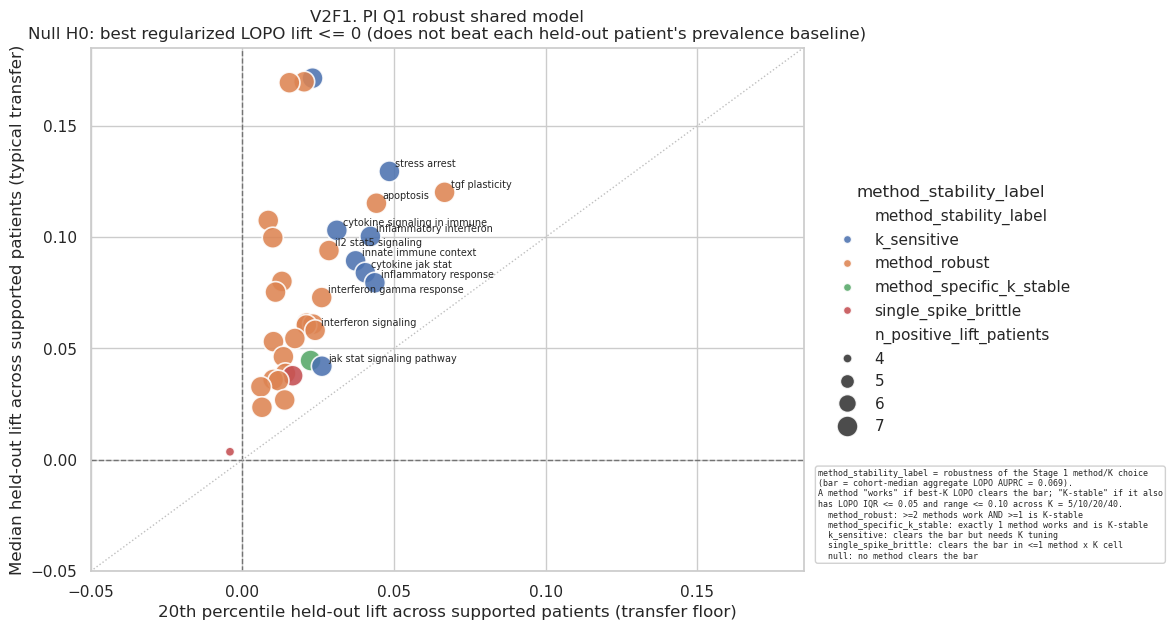

/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/figures/stage2_figure3_sharedness_v2_jun4/diagnostic_layer1_layer2/v2F2_priority_panel_method_k_lopo_curves.png


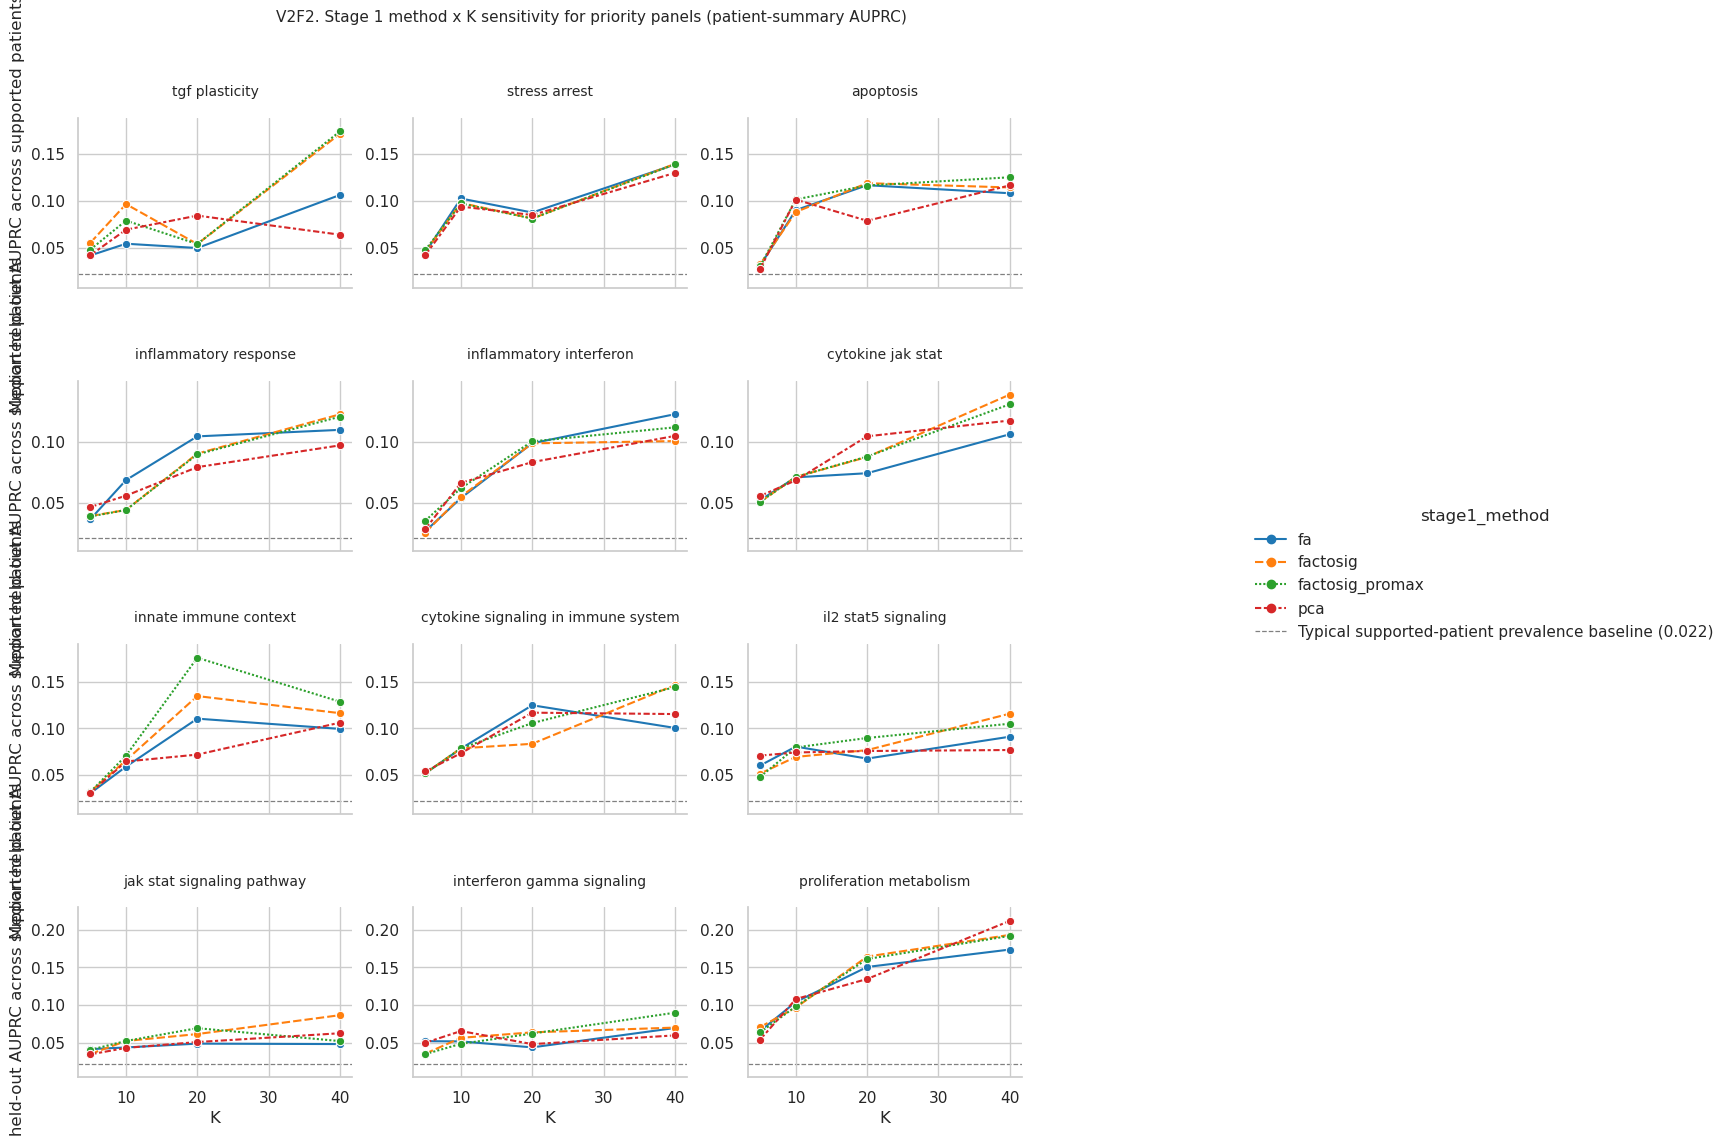

,requested_label,matched,matched_short_panel_label,stage0_panel_id
0,TNFA signaling via NFkB,True,tnfa signaling via nfkb,single_geneset__hallmark_tnfa_signaling_via_nfkb
1,Hypoxia,True,hypoxia,single_geneset__hallmark_hypoxia
2,IFN-alpha response,True,interferon alpha response,single_geneset__hallmark_interferon_alpha_resp...
3,P53 pathway,True,p53 pathway,single_geneset__hallmark_p53_pathway
4,Complement,True,complement,single_geneset__hallmark_complement
5,Inflammatory response,True,inflammatory response,single_geneset__hallmark_inflammatory_response
6,Apoptosis,True,apoptosis,single_geneset__hallmark_apoptosis
7,EMT,True,epithelial mesenchymal transition,single_geneset__hallmark_epithelial_mesenchyma...
8,Myogenesis,False,NaN,NaN
9,HEME metabolism,False,NaN,NaN


/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/figures/stage2_figure3_sharedness_v2_jun4/diagnostic_layer1_layer2/v2F2b_requested_panel_method_k_lopo_curves.png


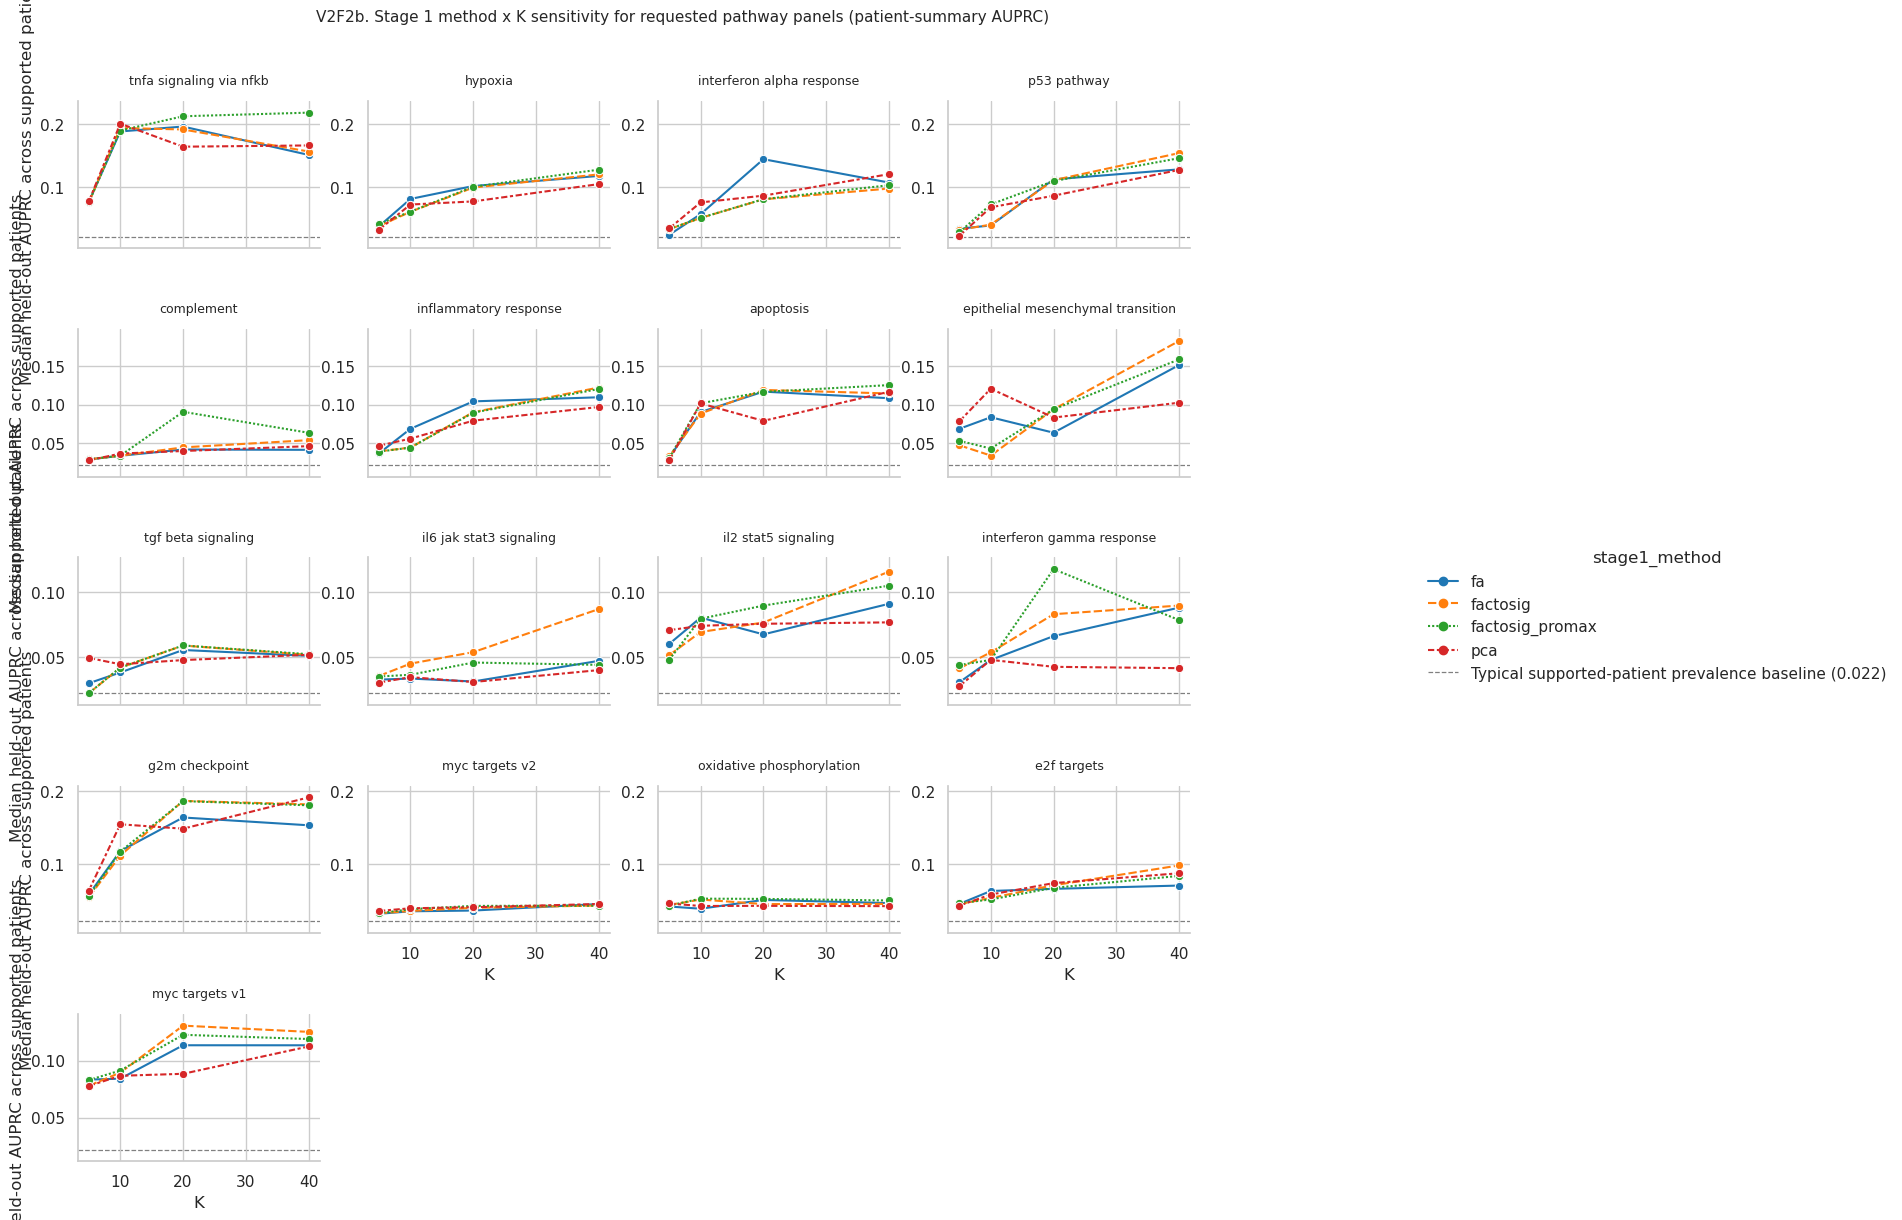

/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/figures/stage2_figure3_sharedness_v2_jun4/diagnostic_layer1_layer2/v2F2c_requested_panel_method_k_patient_lift_curves.png


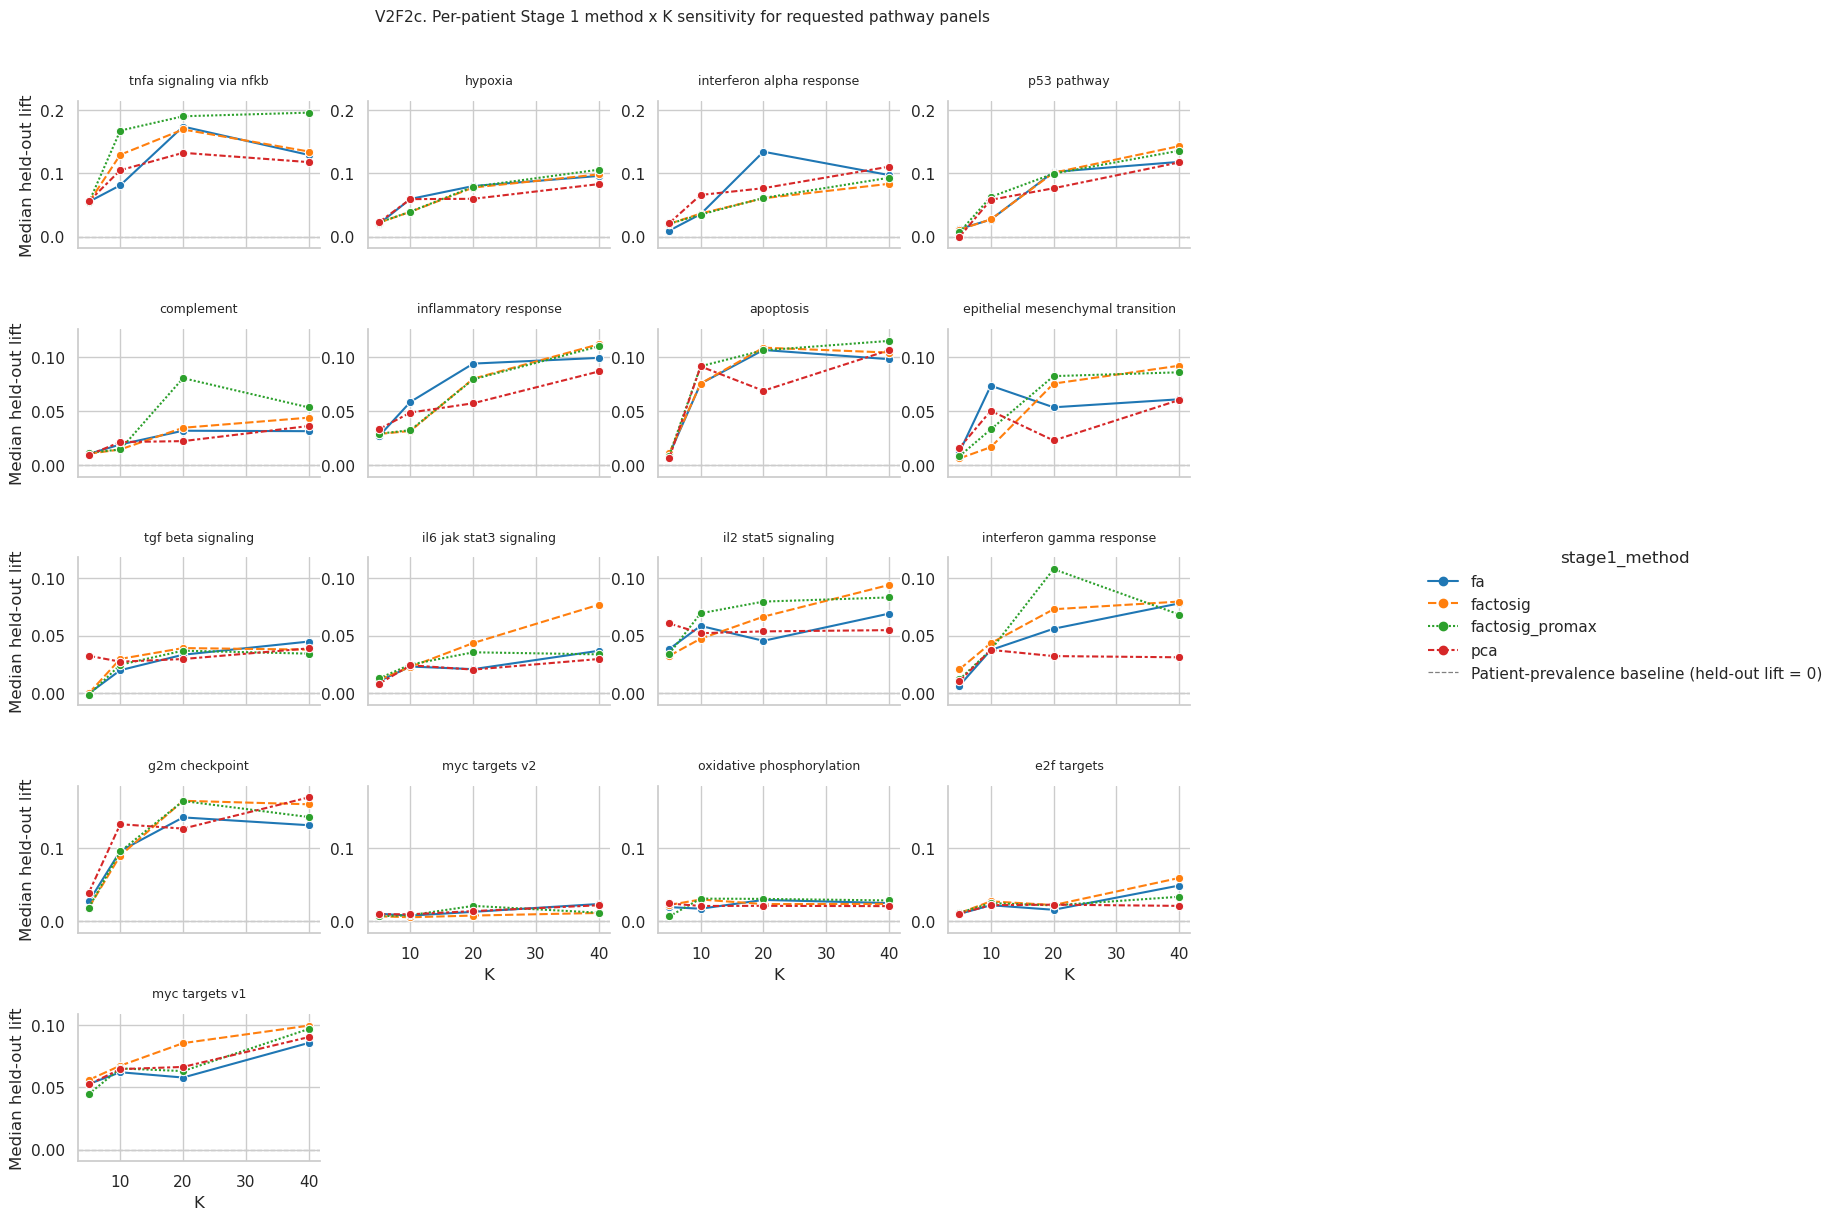

/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/figures/stage2_figure3_sharedness_v2_jun4/diagnostic_layer1_layer2/v2F3_panel_method_median_lift_heatmap.png


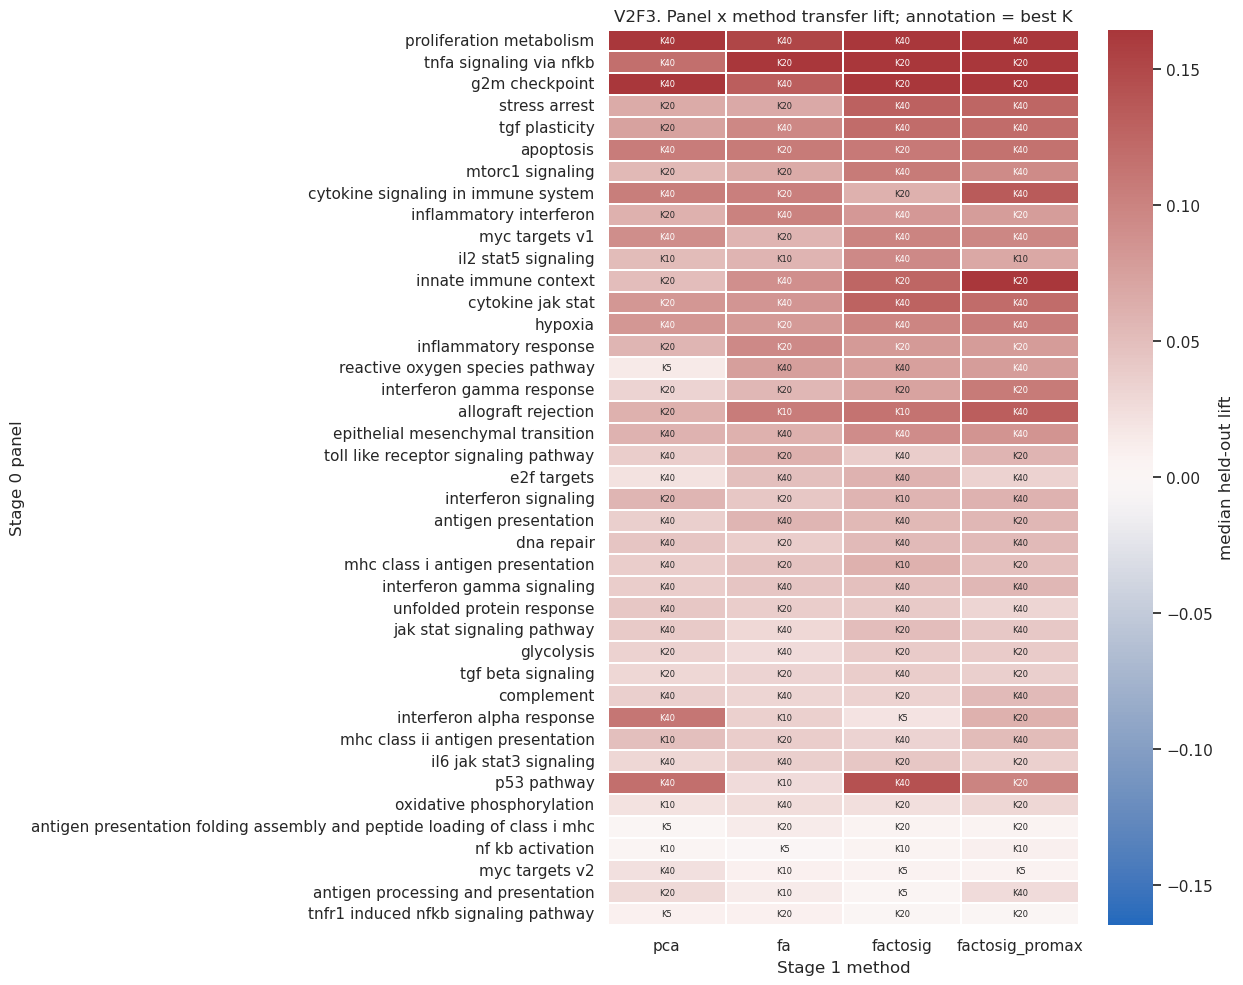

/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/figures/stage2_figure3_sharedness_v2_jun4/diagnostic_layer1_layer2/v2F4_panel_patient_heldout_lift_heatmap.png


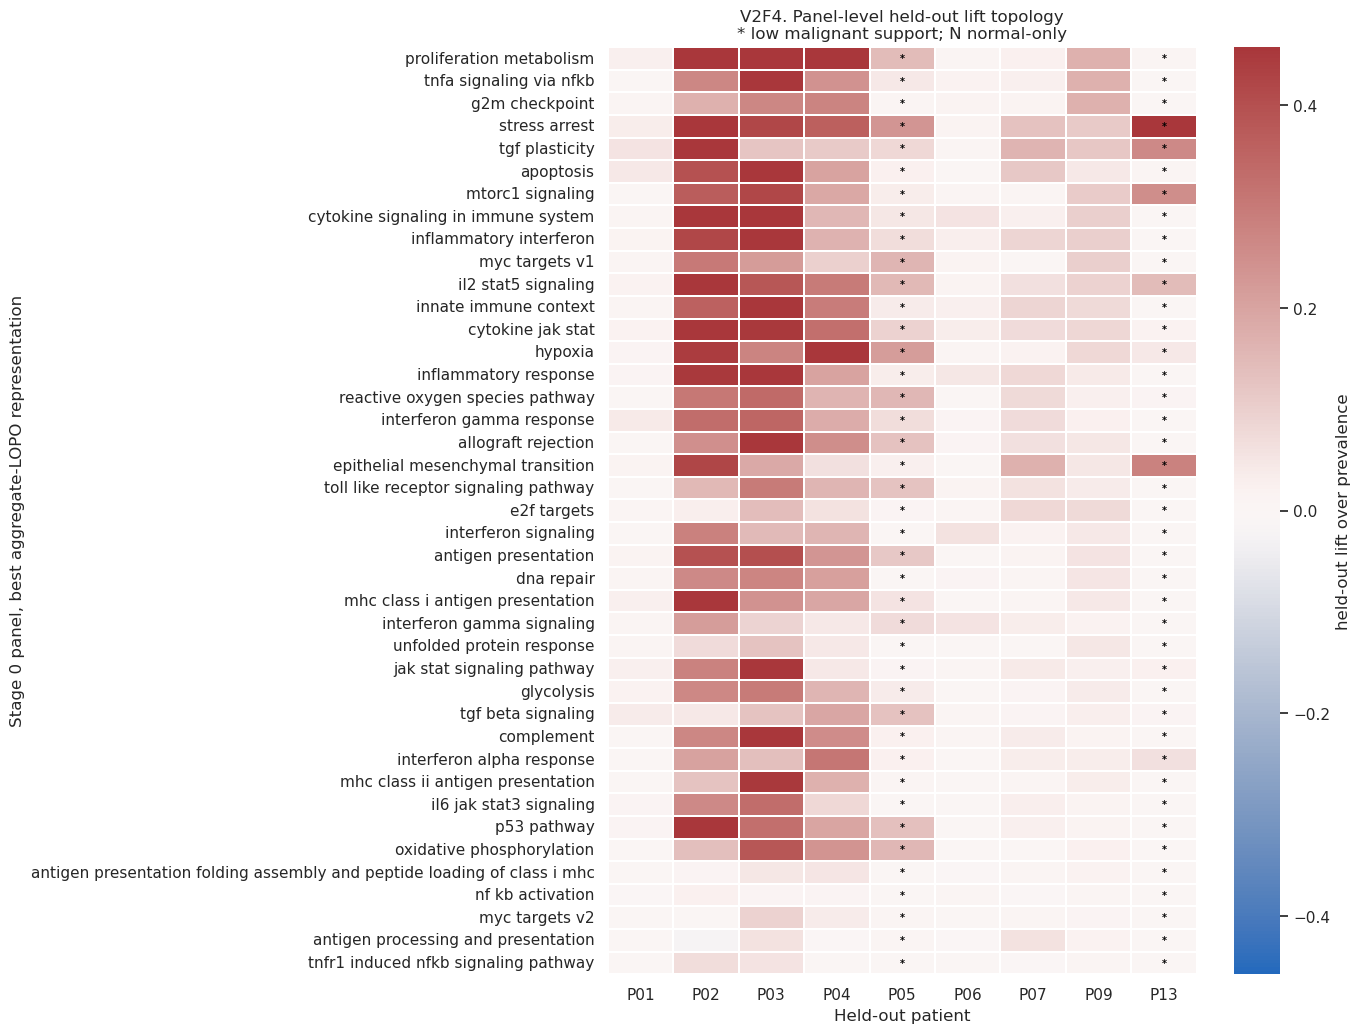

/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/figures/stage2_figure3_sharedness_v2_jun4/diagnostic_layer1_layer2/v2F5_patient_leverage_scatter.png


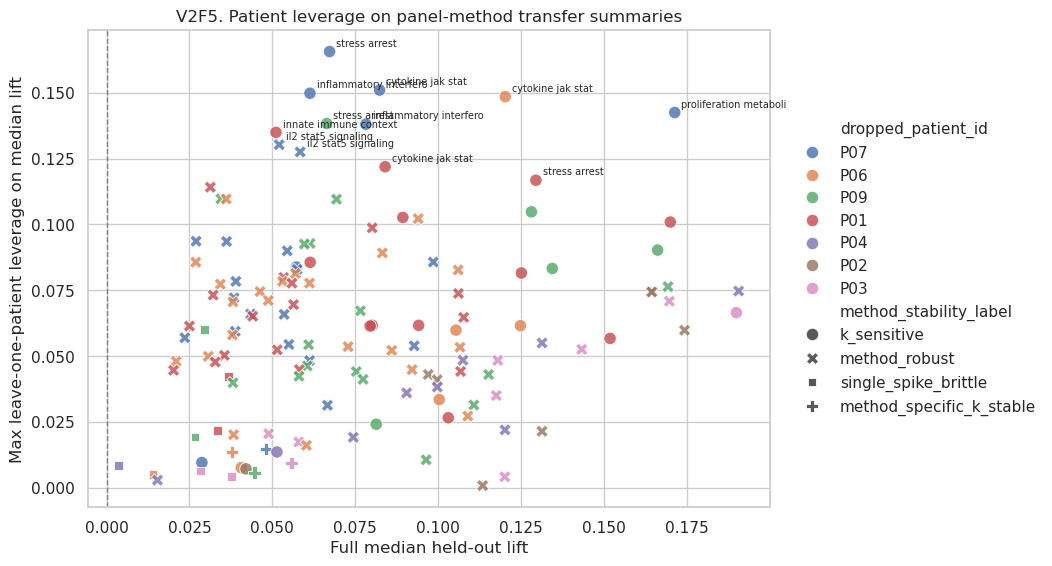

/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/figures/stage2_figure3_sharedness_v2_jun4/diagnostic_layer1_layer2/v2F6_theme_transfer_and_stability_summary.png


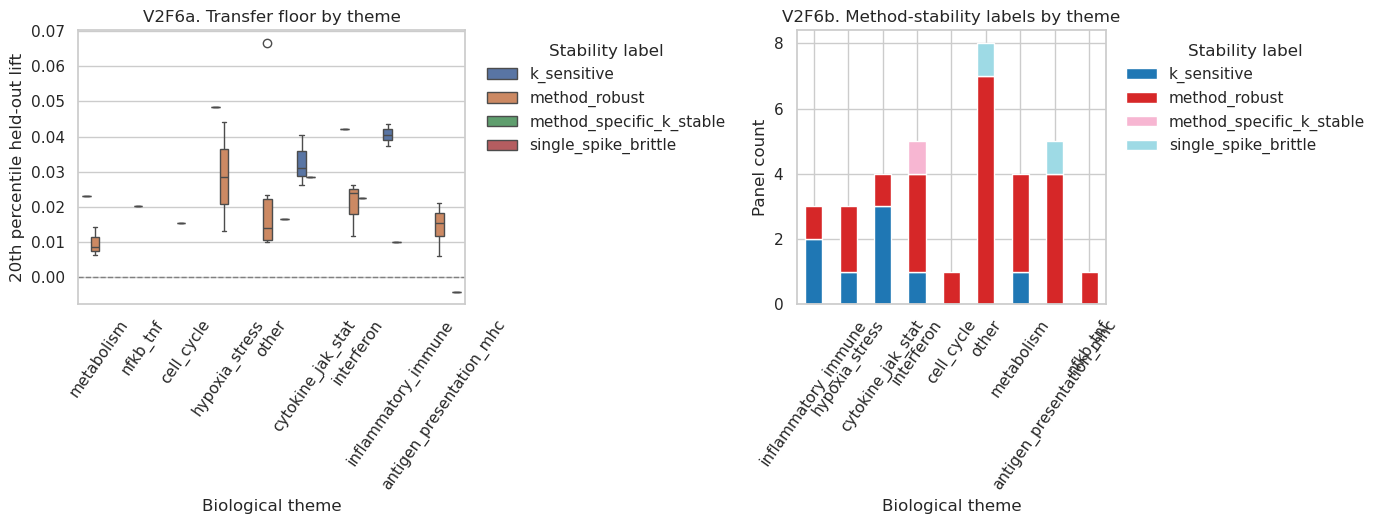

Wrote diagnostic plots to /home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/figures/stage2_figure3_sharedness_v2_jun4/diagnostic_layer1_layer2
Priority panels for method x K curves:
 - tgf plasticity: method_robust
 - stress arrest: k_sensitive
 - apoptosis: method_robust
 - inflammatory response: k_sensitive
 - inflammatory interferon: k_sensitive
 - cytokine jak stat: k_sensitive
 - innate immune context: k_sensitive
 - cytokine signaling in immune system: k_sensitive
 - il2 stat5 signaling: method_robust
 - jak stat signaling pathway: k_sensitive
 - interferon gamma signaling: method_specific_k_stable
 - proliferation metabolism: k_sensitive


In [9]:
# Diagnostic plots from the new panel-level CSVs.
from matplotlib.lines import Line2D

DIAGNOSTIC_PLOT_DIR = OUTPUT_DIR / 'diagnostic_layer1_layer2'
DIAGNOSTIC_PLOT_DIR.mkdir(parents=True, exist_ok=True)

decision_plot = pd.read_csv(TABLE_DIR / 'v2_decision_table_discovery_lopo_patient_specific.csv', low_memory=False)
panel_stability_plot = pd.read_csv(TABLE_DIR / 'v2_panel_stage1_stability_summary.csv', low_memory=False)
panel_method_stability_plot = pd.read_csv(TABLE_DIR / 'v2_panel_method_stage1_stability_summary.csv', low_memory=False)
panel_method_k_plot = pd.read_csv(TABLE_DIR / 'v2_panel_method_k_lopo_distribution.csv', low_memory=False)
panel_patient_plot = pd.read_csv(TABLE_DIR / 'v2_panel_lopo_patient_summary.csv', low_memory=False)
panel_method_patient_plot = pd.read_csv(TABLE_DIR / 'v2_panel_method_lopo_patient_summary.csv', low_memory=False)
transfer_plot = pd.read_csv(TABLE_DIR / 'v2_panel_lopo_patient_transfer_long.csv', low_memory=False)
leverage_plot = pd.read_csv(TABLE_DIR / 'v2_patient_leverage_on_panel_method_median_lift.csv', low_memory=False)
LOPO_HIGH_THRESHOLD = float(decision_plot['lopo_auprc'].median())


def add_facet_reference_line_legend(facet, label: str) -> None:
    leg = facet._legend
    if leg is None:
        return
    if hasattr(leg, 'legend_handles'):
        handles = list(leg.legend_handles)
    elif hasattr(leg, 'legendHandles'):
        handles = list(leg.legendHandles)
    else:
        handles = list(leg.get_lines())
    labels = [text.get_text() for text in leg.texts]
    handles.append(Line2D([0], [0], color='0.5', lw=0.9, ls='--'))
    labels.append(label)
    title = leg.get_title().get_text() if leg.get_title() else None
    leg.remove()
    facet._legend = facet.fig.legend(
        handles,
        labels,
        title=title,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )


stability_cols = [
    'stage0_panel_id', 'method_stability_label', 'n_working_methods',
    'n_k_stable_working_methods', 'n_shared_candidate_combos', 'best_lopo_stage1_method',
]
panel_readiness = panel_patient_plot.merge(panel_stability_plot[stability_cols], on='stage0_panel_id', how='left')
panel_readiness.to_csv(TABLE_DIR / 'v2_panel_shortlist_readiness_plot_source.csv', index=False)

# Patient-summary aggregate metric (Option B): summarize each held-out patient first, then take the
# median across supported patients. This replaces the cell-weighted "aggregate LOPO AUPRC", which is
# dominated by patients with many malignant cells (P02/P03). See figure catalog .md, section 0.
CORE_STAGE1_METHODS_PLOT = ['pca', 'fa', 'factosig', 'factosig_promax']


def get_lopo_patient_best_for_plot() -> pd.DataFrame:
    if 'lopo_patient_best' in globals():
        return lopo_patient_best.copy()
    if 'lopo_by_patient' in globals():
        source = lopo_by_patient.copy()
    else:
        source = add_plot_labels(pd.read_csv(MULTIOBJ_DIR / 'sharedness_lopo' / 'by_heldout_patient.csv', low_memory=False))
    return select_regularization_rows(
        source,
        group_cols=['representation_id', 'heldout_patient_id'],
        metric_col='stage2_auprc',
        mode=SELECTION_MODE,
        penalty_priority=PENALTY_PRIORITY,
    )


def build_patient_summary_k(source: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = source.copy()
    df['effective_k'] = pd.to_numeric(df['effective_k'], errors='coerce')
    if 'heldout_auprc' not in df.columns:
        df['heldout_auprc'] = pd.to_numeric(df['selected_metric_value'], errors='coerce')
    df['heldout_auprc'] = pd.to_numeric(df['heldout_auprc'], errors='coerce')
    if 'malignant_prevalence' not in df.columns:
        mal_col = resolve_col(df, ['n_test_malignant', 'n_malignant'], required=False)
        norm_col = resolve_col(df, ['n_test_non_malignant', 'n_normal'], required=False)
        if mal_col and norm_col:
            malignant = pd.to_numeric(df[mal_col], errors='coerce')
            normal = pd.to_numeric(df[norm_col], errors='coerce')
            df['malignant_prevalence'] = malignant / (malignant + normal).replace(0, np.nan)
            df['normal_only'] = malignant.fillna(0).eq(0) & normal.fillna(0).gt(0)
            df['low_malignant_support'] = malignant.gt(0) & malignant.lt(MIN_MALIGNANT_SUPPORT)
        else:
            df['malignant_prevalence'] = np.nan
    df['heldout_lift'] = df['heldout_auprc'] - pd.to_numeric(df['malignant_prevalence'], errors='coerce')
    normal_only = pd.Series(df.get('normal_only', False), index=df.index).astype('boolean').fillna(False)
    low_support = pd.Series(df.get('low_malignant_support', False), index=df.index).astype('boolean').fillna(False)
    df['supported_patient'] = ~normal_only & ~low_support & df['heldout_lift'].notna()
    supported = df.loc[df['supported_patient'] & df['stage1_method'].isin(CORE_STAGE1_METHODS_PLOT)].copy()
    summary = (
        supported.groupby(['stage0_panel_id', 'short_panel_label', 'stage1_method', 'effective_k'], observed=False)
        .agg(
            patient_median_auprc=('heldout_auprc', 'median'),
            patient_median_lift=('heldout_lift', 'median'),
            patient_p20_lift=('heldout_lift', lambda x: x.quantile(0.20)),
            n_supported_patients=('heldout_patient_id', 'nunique'),
        )
        .reset_index()
        .dropna(subset=['patient_median_auprc'])
    )
    return summary, supported


patient_k_all = get_lopo_patient_best_for_plot()
patient_summary_k, patient_supported_long = build_patient_summary_k(patient_k_all)
patient_summary_k.to_csv(TABLE_DIR / 'v2_panel_method_k_patient_summary_auprc.csv', index=False)
# Typical supported-patient prevalence = median random-ranker AUPRC baseline across supported patients.
TYPICAL_SUPPORTED_PREVALENCE = float(
    patient_supported_long[['heldout_patient_id', 'malignant_prevalence']]
    .drop_duplicates()['malignant_prevalence']
    .median()
)

# 1. Shortlist readiness: transfer floor vs typical transfer (PI Q1: robust shared model).
fig, ax = plt.subplots(figsize=(9.2, 6.8))
sns.scatterplot(
    data=panel_readiness,
    x='p20_heldout_lift',
    y='median_heldout_lift',
    hue='method_stability_label',
    size='n_positive_lift_patients',
    sizes=(45, 230),
    alpha=0.88,
    ax=ax,
)
ax.axhline(0, color='0.45', lw=1, ls='--')
ax.axvline(0, color='0.45', lw=1, ls='--')
lim_max = max(panel_readiness[['p20_heldout_lift', 'median_heldout_lift']].max().max() * 1.08, 0.05)
lim_min = min(panel_readiness[['p20_heldout_lift', 'median_heldout_lift']].min().min() * 1.08, -0.05)
ax.plot([lim_min, lim_max], [lim_min, lim_max], color='0.75', lw=1, ls=':')
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.set_xlabel('20th percentile held-out lift across supported patients (transfer floor)')
ax.set_ylabel('Median held-out lift across supported patients (typical transfer)')
ax.set_title(
    'V2F1. PI Q1 robust shared model\n'
    "Null H0: best regularized LOPO lift <= 0 (does not beat each held-out patient's prevalence baseline)"
)
label_source = panel_readiness.sort_values(['p20_heldout_lift', 'median_heldout_lift'], ascending=False).head(12)
for _, row in label_source.iterrows():
    ax.text(row['p20_heldout_lift'] + 0.002, row['median_heldout_lift'] + 0.002, str(row['short_panel_label'])[:28], fontsize=7)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, title='method_stability_label')
stability_note = '\n'.join([
    'method_stability_label = robustness of the Stage 1 method/K choice',
    f'(bar = cohort-median aggregate LOPO AUPRC = {LOPO_HIGH_THRESHOLD:.3f}).',
    'A method "works" if best-K LOPO clears the bar; "K-stable" if it also',
    'has LOPO IQR <= 0.05 and range <= 0.10 across K = 5/10/20/40.',
    '  method_robust: >=2 methods work AND >=1 is K-stable',
    '  method_specific_k_stable: exactly 1 method works and is K-stable',
    '  k_sensitive: clears the bar but needs K tuning',
    '  single_spike_brittle: clears the bar in <=1 method x K cell',
    '  null: no method clears the bar',
])
ax.text(
    1.02, 0.02, stability_note,
    transform=ax.transAxes, fontsize=6, va='bottom', ha='left', family='monospace',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='0.8', alpha=0.9),
)
savefig(fig, DIAGNOSTIC_PLOT_DIR / 'v2F1_panel_shortlist_readiness_lift_scatter.png')
plt.show()

# 2. Method x K curves for priority panels (patient-summary aggregate AUPRC, Option B).
priority_panels = (
    panel_readiness.sort_values(['p20_heldout_lift', 'median_heldout_lift'], ascending=False)
    .head(10)['stage0_panel_id']
    .tolist()
)
# Add a few non-robust examples so the plot teaches the label taxonomy.
for label in ['method_specific_k_stable', 'k_sensitive', 'single_spike_brittle', 'null']:
    extra = panel_readiness.loc[panel_readiness['method_stability_label'].eq(label)].sort_values('median_heldout_lift', ascending=False).head(1)['stage0_panel_id'].tolist()
    priority_panels.extend(extra)
priority_panels = list(dict.fromkeys(priority_panels))[:12]
priority_k = patient_summary_k.loc[patient_summary_k['stage0_panel_id'].isin(priority_panels)].copy()
priority_k['effective_k'] = pd.to_numeric(priority_k['effective_k'], errors='coerce')
priority_k['panel_order'] = pd.Categorical(priority_k['stage0_panel_id'], categories=priority_panels, ordered=True)
priority_k = priority_k.sort_values(['panel_order', 'stage1_method', 'effective_k'])
method_palette = dict(zip(sorted(priority_k['stage1_method'].dropna().unique()), sns.color_palette('tab10', n_colors=priority_k['stage1_method'].nunique())))
V2F2_COL_WRAP = 3
g = sns.relplot(
    data=priority_k,
    x='effective_k',
    y='patient_median_auprc',
    hue='stage1_method',
    style='stage1_method',
    kind='line',
    marker='o',
    col='short_panel_label',
    col_wrap=V2F2_COL_WRAP,
    height=2.85,
    aspect=1.25,
    palette=method_palette,
    facet_kws={'sharey': False, 'sharex': True},
)
axes = np.asarray(g.axes).ravel()
n_axes = len(axes)
n_rows = int(np.ceil(n_axes / V2F2_COL_WRAP))
for ax in axes:
    ax.axhline(TYPICAL_SUPPORTED_PREVALENCE, color='0.5', lw=0.9, ls='--', zorder=0)
for row in range(n_rows):
    row_axes = axes[row * V2F2_COL_WRAP:min((row + 1) * V2F2_COL_WRAP, n_axes)]
    if len(row_axes) == 0:
        continue
    y_min = min(min(ax.get_ylim()[0] for ax in row_axes), TYPICAL_SUPPORTED_PREVALENCE)
    y_max = max(max(ax.get_ylim()[1] for ax in row_axes), TYPICAL_SUPPORTED_PREVALENCE)
    y_pad = 0.04 * (y_max - y_min) if y_max > y_min else 0.01
    for ax in row_axes:
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
for i, ax in enumerate(axes):
    ax.set_xlabel('K')
    ax.set_ylabel('Median held-out AUPRC across supported patients' if i % V2F2_COL_WRAP == 0 else '')
g.set_titles('{col_name}', size=10, pad=16)
g.fig.subplots_adjust(hspace=0.55, wspace=0.22, top=0.90)
g.fig.suptitle(
    'V2F2. Stage 1 method x K sensitivity for priority panels (patient-summary AUPRC)',
    y=0.995,
    fontsize=11,
)
add_facet_reference_line_legend(
    g,
    f'Typical supported-patient prevalence baseline ({TYPICAL_SUPPORTED_PREVALENCE:.3f})',
)
savefig(g.fig, DIAGNOSTIC_PLOT_DIR / 'v2F2_priority_panel_method_k_lopo_curves.png')
plt.show()

# 2b. Method x K curves for a requested pathway panel set.
REQUESTED_V2F2_PANELS = [
    'TNFA signaling via NFkB',
    'Hypoxia',
    'IFN-alpha response',
    'P53 pathway',
    'Complement',
    'Inflammatory response',
    'Apoptosis',
    'EMT',
    'Myogenesis',
    'HEME metabolism',
    'TGF-Beta signaling',
    'IL6 JAK Stat3 signaling',
    'IL-2 stat5 signaling',
    'IFN-gamma response',
    'G2M checkpoint',
    'MYC targets V2',
    'OXPHOS',
    'E2F targets',
    'MYC targets V1',
]
REQUESTED_V2F2_ALIASES = {
    'EMT': 'epithelial mesenchymal transition',
    'IFN-alpha response': 'interferon alpha response',
    'IFN-gamma response': 'interferon gamma response',
    'IL-2 stat5 signaling': 'il2 stat5 signaling',
    'OXPHOS': 'oxidative phosphorylation',
}


def normalize_panel_label(value: str) -> str:
    text = str(value).lower()
    text = text.replace('nf-kb', 'nfkb').replace('nf kb', 'nfkb')
    text = text.replace('ifn', 'interferon')
    text = text.replace('tnfa', 'tnfa')
    text = re.sub(r'[^a-z0-9]+', ' ', text)
    return text.strip()


def align_facet_y_by_row(facet, col_wrap: int, reference_value: float | None = None) -> None:
    axes = np.asarray(facet.axes).ravel()
    n_rows = int(np.ceil(len(axes) / col_wrap))
    for row in range(n_rows):
        row_axes = axes[row * col_wrap:min((row + 1) * col_wrap, len(axes))]
        if len(row_axes) == 0:
            continue
        y_min = min(ax.get_ylim()[0] for ax in row_axes)
        y_max = max(ax.get_ylim()[1] for ax in row_axes)
        if reference_value is not None:
            y_min = min(y_min, reference_value)
            y_max = max(y_max, reference_value)
        y_pad = 0.04 * (y_max - y_min) if y_max > y_min else 0.01
        for ax in row_axes:
            ax.set_ylim(y_min - y_pad, y_max + y_pad)


panel_lookup = panel_method_k_plot[[
    'stage0_panel_id', 'short_panel_label', 'stage0_panel_type', 'biological_theme'
]].drop_duplicates().copy()
panel_lookup['label_key'] = panel_lookup['short_panel_label'].map(normalize_panel_label)

requested_panel_rows = []
for requested_label in REQUESTED_V2F2_PANELS:
    lookup_label = REQUESTED_V2F2_ALIASES.get(requested_label, requested_label)
    label_key = normalize_panel_label(lookup_label)
    hit = panel_lookup.loc[panel_lookup['label_key'].eq(label_key)].head(1)
    if hit.empty:
        requested_panel_rows.append({
            'requested_label': requested_label,
            'matched': False,
            'matched_short_panel_label': np.nan,
            'stage0_panel_id': np.nan,
        })
    else:
        row = hit.iloc[0]
        requested_panel_rows.append({
            'requested_label': requested_label,
            'matched': True,
            'matched_short_panel_label': row['short_panel_label'],
            'stage0_panel_id': row['stage0_panel_id'],
        })
requested_panel_check = pd.DataFrame(requested_panel_rows)
display(requested_panel_check)

selected_panel_ids = requested_panel_check.loc[requested_panel_check['matched'], 'stage0_panel_id'].tolist()
selected_panel_order = requested_panel_check.loc[requested_panel_check['matched'], 'matched_short_panel_label'].tolist()
selected_k = patient_summary_k.loc[patient_summary_k['stage0_panel_id'].isin(selected_panel_ids)].copy()
selected_k['short_panel_label'] = pd.Categorical(
    selected_k['short_panel_label'],
    categories=selected_panel_order,
    ordered=True,
)
selected_k = selected_k.sort_values(['short_panel_label', 'stage1_method', 'effective_k'])

V2F2_SELECTED_COL_WRAP = 4
if not selected_k.empty:
    g_selected = sns.relplot(
        data=selected_k,
        x='effective_k',
        y='patient_median_auprc',
        hue='stage1_method',
        style='stage1_method',
        kind='line',
        marker='o',
        col='short_panel_label',
        col_order=selected_panel_order,
        col_wrap=V2F2_SELECTED_COL_WRAP,
        height=2.45,
        aspect=1.25,
        palette=method_palette,
        facet_kws={'sharey': False, 'sharex': True},
    )
    for ax in np.asarray(g_selected.axes).ravel():
        ax.axhline(TYPICAL_SUPPORTED_PREVALENCE, color='0.5', lw=0.9, ls='--', zorder=0)
    align_facet_y_by_row(g_selected, V2F2_SELECTED_COL_WRAP, reference_value=TYPICAL_SUPPORTED_PREVALENCE)
    for i, ax in enumerate(np.asarray(g_selected.axes).ravel()):
        ax.set_xlabel('K')
        ax.set_ylabel('Median held-out AUPRC across supported patients' if i % V2F2_SELECTED_COL_WRAP == 0 else '')
    g_selected.set_titles('{col_name}', size=9, pad=12)
    g_selected.fig.subplots_adjust(hspace=0.55, wspace=0.20, top=0.92)
    g_selected.fig.suptitle(
        'V2F2b. Stage 1 method x K sensitivity for requested pathway panels (patient-summary AUPRC)',
        y=0.995,
        fontsize=11,
    )
    add_facet_reference_line_legend(
        g_selected,
        f'Typical supported-patient prevalence baseline ({TYPICAL_SUPPORTED_PREVALENCE:.3f})',
    )
    savefig(g_selected.fig, DIAGNOSTIC_PLOT_DIR / 'v2F2b_requested_panel_method_k_lopo_curves.png')
    plt.show()

# 2c. Per-patient version: patient-summary median held-out lift over each patient's prevalence (Option B, lift form).
patient_curve = patient_summary_k.loc[patient_summary_k['stage0_panel_id'].isin(selected_panel_ids)].copy()
patient_curve = patient_curve.rename(columns={
    'patient_median_lift': 'median_heldout_lift',
    'patient_p20_lift': 'p20_heldout_lift',
})
patient_curve['short_panel_label'] = pd.Categorical(
    patient_curve['short_panel_label'],
    categories=selected_panel_order,
    ordered=True,
)
patient_curve = patient_curve.dropna(subset=['median_heldout_lift'])

if not patient_curve.empty:
    g_patient = sns.relplot(
        data=patient_curve,
        x='effective_k',
        y='median_heldout_lift',
        hue='stage1_method',
        style='stage1_method',
        kind='line',
        marker='o',
        col='short_panel_label',
        col_order=selected_panel_order,
        col_wrap=V2F2_SELECTED_COL_WRAP,
        height=2.45,
        aspect=1.25,
        palette=method_palette,
        facet_kws={'sharey': False, 'sharex': True},
    )
    for ax in np.asarray(g_patient.axes).ravel():
        ax.axhline(0, color='0.5', lw=0.9, ls='--', zorder=0)
    align_facet_y_by_row(g_patient, V2F2_SELECTED_COL_WRAP, reference_value=0)
    for i, ax in enumerate(np.asarray(g_patient.axes).ravel()):
        ax.set_xlabel('K')
        ax.set_ylabel('Median held-out lift' if i % V2F2_SELECTED_COL_WRAP == 0 else '')
    g_patient.set_titles('{col_name}', size=9, pad=12)
    g_patient.fig.subplots_adjust(hspace=0.55, wspace=0.20, top=0.92)
    g_patient.fig.suptitle(
        'V2F2c. Per-patient Stage 1 method x K sensitivity for requested pathway panels',
        y=0.995,
        fontsize=11,
    )
    add_facet_reference_line_legend(
        g_patient,
        'Patient-prevalence baseline (held-out lift = 0)',
    )
    savefig(g_patient.fig, DIAGNOSTIC_PLOT_DIR / 'v2F2c_requested_panel_method_k_patient_lift_curves.png')
    plt.show()

# 3. Panel x method heatmap using held-out lift, annotated by selected K.
method_heat = panel_method_patient_plot.copy()
method_order = ['pca', 'fa', 'factosig', 'factosig_promax']
panel_order = panel_readiness.sort_values(['median_heldout_lift', 'p20_heldout_lift'], ascending=False)['short_panel_label'].tolist()
heat_mat = method_heat.pivot_table(index='short_panel_label', columns='selected_stage1_method', values='median_heldout_lift', aggfunc='mean').reindex(panel_order)[method_order]
k_annot = method_heat.pivot_table(index='short_panel_label', columns='selected_stage1_method', values='selected_effective_k', aggfunc='first').reindex(panel_order)[method_order]
k_annot = k_annot.map(lambda v: '' if pd.isna(v) else f'K{int(v)}')
vmax = float(np.nanpercentile(np.abs(heat_mat.values), 95)) if np.isfinite(heat_mat.values).any() else 0.1
vmax = max(vmax, 0.05)
fig_h = max(7, 0.23 * len(heat_mat) + 2.2)
fig, ax = plt.subplots(figsize=(7.6, fig_h))
sns.heatmap(
    heat_mat,
    cmap='vlag',
    center=0,
    vmin=-vmax,
    vmax=vmax,
    linewidths=0.25,
    linecolor='white',
    annot=k_annot,
    fmt='',
    annot_kws={'fontsize': 6},
    cbar_kws={'label': 'median held-out lift'},
    ax=ax,
)
ax.set_xlabel('Stage 1 method')
ax.set_ylabel('Stage 0 panel')
ax.set_title('V2F3. Panel x method transfer lift; annotation = best K')
savefig(fig, DIAGNOSTIC_PLOT_DIR / 'v2F3_panel_method_median_lift_heatmap.png')
plt.show()

# 4. Patient transfer topology using lift instead of raw AUPRC/enrichment.
panel_transfer = transfer_plot.loc[transfer_plot['summary_scope'].eq('panel_best_lopo')].copy()
panel_transfer['panel_label_order'] = pd.Categorical(panel_transfer['short_panel_label'], categories=panel_order, ordered=True)
panel_transfer = panel_transfer.sort_values(['panel_label_order', 'heldout_patient_id'])
lift_mat = panel_transfer.pivot_table(index='short_panel_label', columns='heldout_patient_id', values='heldout_lift', aggfunc='mean').reindex(panel_order)
support_flags = panel_transfer.set_index(['short_panel_label', 'heldout_patient_id'])
vmax = float(np.nanpercentile(np.abs(lift_mat.values), 95)) if np.isfinite(lift_mat.values).any() else 0.1
vmax = max(vmax, 0.05)
fig_h = max(7, 0.24 * len(lift_mat) + 2.2)
fig, ax = plt.subplots(figsize=(9.5, fig_h))
sns.heatmap(
    lift_mat,
    cmap='vlag',
    center=0,
    vmin=-vmax,
    vmax=vmax,
    linewidths=0.25,
    linecolor='white',
    cbar_kws={'label': 'held-out lift over prevalence'},
    ax=ax,
)
for y, panel_label in enumerate(lift_mat.index):
    for x, patient in enumerate(lift_mat.columns):
        mark = ''
        if (panel_label, patient) in support_flags.index:
            rec = support_flags.loc[(panel_label, patient)]
            if isinstance(rec, pd.DataFrame):
                rec = rec.iloc[0]
            if bool(rec.get('normal_only', False)):
                mark = 'N'
            elif bool(rec.get('low_malignant_support', False)):
                mark = '*'
        if mark:
            ax.text(x + 0.5, y + 0.5, mark, ha='center', va='center', color='black', fontsize=7, fontweight='bold')
ax.set_xlabel('Held-out patient')
ax.set_ylabel('Stage 0 panel, best aggregate-LOPO representation')
ax.set_title('V2F4. Panel-level held-out lift topology\n* low malignant support; N normal-only')
savefig(fig, DIAGNOSTIC_PLOT_DIR / 'v2F4_panel_patient_heldout_lift_heatmap.png')
plt.show()

# 5. Patient leverage: identify panel/method transfer summaries driven by one patient.
max_leverage = (
    leverage_plot.sort_values('patient_leverage_abs_delta', ascending=False)
    .drop_duplicates(['stage0_panel_id', 'selected_stage1_method'])
    .merge(panel_stability_plot[['stage0_panel_id', 'method_stability_label']], on='stage0_panel_id', how='left')
)
fig, ax = plt.subplots(figsize=(8.8, 6.2))
sns.scatterplot(
    data=max_leverage,
    x='full_median_heldout_lift',
    y='patient_leverage_abs_delta',
    hue='dropped_patient_id',
    style='method_stability_label',
    alpha=0.82,
    s=80,
    ax=ax,
)
ax.axvline(0, color='0.5', lw=1, ls='--')
ax.set_xlabel('Full median held-out lift')
ax.set_ylabel('Max leave-one-patient leverage on median lift')
ax.set_title('V2F5. Patient leverage on panel-method transfer summaries')
for _, row in max_leverage.sort_values('patient_leverage_abs_delta', ascending=False).head(12).iterrows():
    ax.text(row['full_median_heldout_lift'] + 0.002, row['patient_leverage_abs_delta'] + 0.002, str(row['short_panel_label'])[:22], fontsize=7)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
savefig(fig, DIAGNOSTIC_PLOT_DIR / 'v2F5_patient_leverage_scatter.png')
plt.show()

# 6. Theme summary: are biology themes enriched for robust, broad-transfer panels?
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), gridspec_kw={'width_ratios': [1.25, 1]})
sns.boxplot(
    data=panel_readiness,
    x='biological_theme',
    y='p20_heldout_lift',
    hue='method_stability_label',
    ax=axes[0],
)
axes[0].axhline(0, color='0.5', lw=1, ls='--')
axes[0].set_xlabel('Biological theme')
axes[0].set_ylabel('20th percentile held-out lift')
axes[0].set_title('V2F6a. Transfer floor by theme')
axes[0].tick_params(axis='x', rotation=55)
axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False, title='Stability label')

theme_counts = pd.crosstab(panel_readiness['biological_theme'], panel_readiness['method_stability_label'])
theme_counts = theme_counts.reindex(panel_readiness.groupby('biological_theme')['p20_heldout_lift'].median().sort_values(ascending=False).index)
theme_counts.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_xlabel('Biological theme')
axes[1].set_ylabel('Panel count')
axes[1].set_title('V2F6b. Method-stability labels by theme')
axes[1].tick_params(axis='x', rotation=55)
axes[1].legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False, title='Stability label')
fig.tight_layout()
savefig(fig, DIAGNOSTIC_PLOT_DIR / 'v2F6_theme_transfer_and_stability_summary.png')
plt.show()

print('Wrote diagnostic plots to', DIAGNOSTIC_PLOT_DIR)
print('Priority panels for method x K curves:')
for panel_id in priority_panels:
    label = panel_readiness.loc[panel_readiness['stage0_panel_id'].eq(panel_id), 'short_panel_label'].iloc[0]
    stability = panel_readiness.loc[panel_readiness['stage0_panel_id'].eq(panel_id), 'method_stability_label'].iloc[0]
    print(f' - {label}: {stability}')

## C. Patient-Specific Models: Find Examples, Not Just Averages

This plot asks whether a representation is weak as an aggregate shared model but strong for at least one patient-specific model. Those are candidate examples for new patient-specific biology.

/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/figures/stage2_figure3_sharedness_v2_jun4/v2C_patient_specific_opportunity_map.png


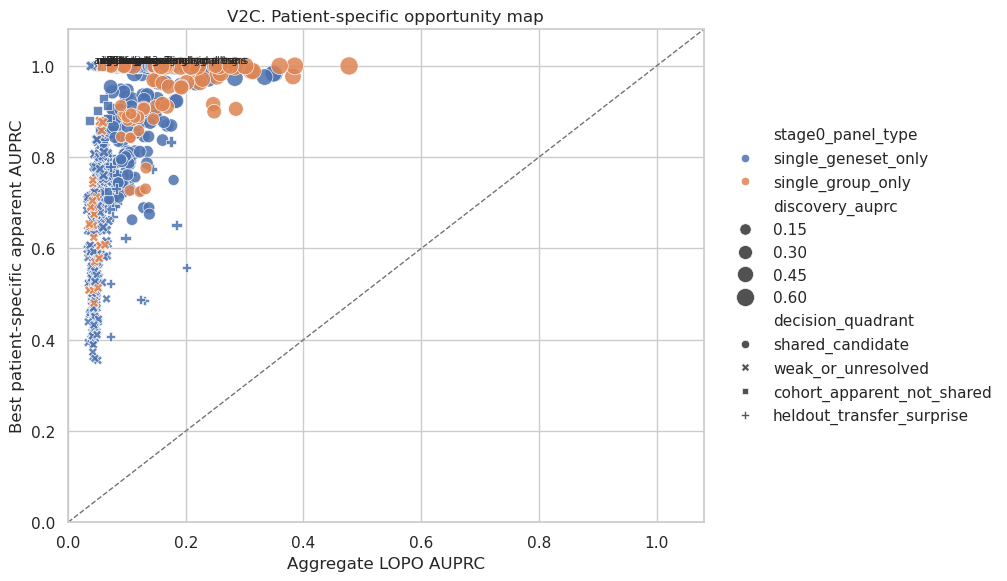

,short_panel_label,stage0_panel_type,stage1_method,effective_k,discovery_auprc,lopo_auprc,max_patient_auprc,patient_specific_gap
378,antigen processing and presentation,single_geneset_only,fa,40,0.117196,0.038803,1.0,0.961197
258,myc targets v2,single_geneset_only,factosig_promax,40,0.058547,0.040866,1.0,0.959134
262,myc targets v2,single_geneset_only,factosig,40,0.060228,0.043782,1.0,0.956218
266,myc targets v2,single_geneset_only,fa,40,0.061725,0.045789,1.0,0.954211
74,e2f targets,single_geneset_only,fa,40,0.091148,0.047641,1.0,0.952359
81,epithelial mesenchymal transition,single_geneset_only,factosig_promax,20,0.250011,0.049309,1.0,0.950691
78,e2f targets,single_geneset_only,pca,40,0.095097,0.050609,1.0,0.949391
162,il6 jak stat3 signaling,single_geneset_only,factosig_promax,40,0.168053,0.050649,1.0,0.949351
447,interferon gamma signaling,single_geneset_only,factosig_promax,40,0.124574,0.050882,1.0,0.949118
330,tgf beta signaling,single_geneset_only,fa,40,0.143477,0.051390,1.0,0.948610


In [10]:
fig, ax = plt.subplots(figsize=(8.2, 6.4))
ps = decision.dropna(subset=['lopo_auprc', 'max_patient_auprc']).copy()
sns.scatterplot(
    data=ps,
    x='lopo_auprc',
    y='max_patient_auprc',
    hue='stage0_panel_type',
    style='decision_quadrant',
    size='discovery_auprc',
    sizes=(40, 180),
    alpha=0.85,
    ax=ax,
)
lims = [0, max(ps[['lopo_auprc', 'max_patient_auprc']].max().max() * 1.08, 0.1)]
ax.plot(lims, lims, color='0.45', ls='--', lw=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Aggregate LOPO AUPRC')
ax.set_ylabel('Best patient-specific apparent AUPRC')
ax.set_title('V2C. Patient-specific opportunity map')
for _, row in ps.sort_values('patient_specific_gap', ascending=False).head(12).iterrows():
    ax.text(row['lopo_auprc'] + 0.006, row['max_patient_auprc'] + 0.006, str(row['short_panel_label'])[:28], fontsize=7)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
savefig(fig, OUTPUT_DIR / 'v2C_patient_specific_opportunity_map.png')
plt.show()

patient_examples = ps.sort_values('patient_specific_gap', ascending=False).head(25)
patient_examples.to_csv(TABLE_DIR / 'v2C_top_patient_specific_gap_candidates.csv', index=False)
display(patient_examples[['short_panel_label', 'stage0_panel_type', 'stage1_method', 'effective_k', 'discovery_auprc', 'lopo_auprc', 'max_patient_auprc', 'patient_specific_gap']].head(15))

## D. Breaking Apart Programs: Coefficients Back To Factor Loadings

The factor-usage heatmaps are Stage 2 logistic-regression coefficients on Stage 1 factors. They are not raw gene weights. To interpret a selected factor biologically, map the selected coefficient-bearing factor back through the Stage 1 loading matrix to the genes with the largest positive and negative loadings.

In [11]:
def parse_factor_index(feature_id: str) -> int | None:
    m = re.search(r'(?:factor|component|PC)[_\- ]*(\d+)', str(feature_id), flags=re.IGNORECASE)
    if not m:
        return None
    return int(m.group(1)) - 1


def load_genes(gene_list_path: str | float | None) -> list[str]:
    if gene_list_path is None or pd.isna(gene_list_path):
        return []
    path = Path(str(gene_list_path))
    if not path.is_absolute():
        path = EXP_DIR / path
    if not path.exists():
        return []
    with path.open() as handle:
        payload = json.load(handle)
    return list(payload.get('genes', []))


def load_stage1_loadings(row: pd.Series) -> tuple[np.ndarray | None, list[str]]:
    metadata_path = row.get('stage1_metadata_path')
    gene_list_path = row.get('gene_list_path')
    loadings_path = None
    if isinstance(metadata_path, str) and metadata_path and metadata_path != 'nan':
        mp = Path(metadata_path)
        if not mp.is_absolute():
            mp = EXP_DIR / mp
        if mp.exists():
            with mp.open() as handle:
                metadata = json.load(handle)
            loadings_path = metadata.get('loadings_path')
    if loadings_path is None:
        return None, load_genes(gene_list_path)
    lp = Path(loadings_path)
    if not lp.is_absolute():
        lp = EXP_DIR / lp
    if not lp.exists():
        return None, load_genes(gene_list_path)
    return np.load(lp), load_genes(gene_list_path)


def top_loading_genes_for_features(row: pd.Series, feature_ids: list[str], top_n: int = 12) -> pd.DataFrame:
    loadings, genes = load_stage1_loadings(row)
    if loadings is None or len(genes) == 0:
        return pd.DataFrame()
    # Most Stage 1 artifacts are genes x factors. Transpose if needed.
    if loadings.shape[0] != len(genes) and loadings.shape[1] == len(genes):
        loadings = loadings.T
    records = []
    for feature_id in feature_ids:
        idx = parse_factor_index(feature_id)
        if idx is None or idx < 0 or idx >= loadings.shape[1]:
            continue
        weights = pd.Series(loadings[:, idx], index=genes).dropna()
        for direction, vals in [('positive', weights.sort_values(ascending=False).head(top_n)), ('negative', weights.sort_values(ascending=True).head(top_n))]:
            for gene, loading in vals.items():
                records.append({
                    'representation_id': row['representation_id'],
                    'stage0_panel_id': row['stage0_panel_id'],
                    'short_panel_label': row.get('short_panel_label', row['stage0_panel_id']),
                    'feature_id': feature_id,
                    'direction': direction,
                    'gene': gene,
                    'loading': float(loading),
                })
    return pd.DataFrame(records)


def filter_coefficients_to_row(coef_df: pd.DataFrame, row: pd.Series, id_col: str = 'representation_id') -> pd.DataFrame:
    out = coef_df.loc[coef_df[id_col].astype(str).eq(str(row[id_col]))].copy()
    for src, dst in [('discovery_penalty', 'penalty'), ('discovery_C', 'C'), ('discovery_l1_ratio', 'l1_ratio')]:
        if src in row.index and dst in out.columns and pd.notna(row[src]):
            out = out.loc[out[dst].astype(str).eq(str(row[src]))].copy()
    return out


def selected_features_from_coefficients(coef_df: pd.DataFrame, row: pd.Series, top_n: int = 12) -> list[str]:
    sub = filter_coefficients_to_row(coef_df, row)
    if sub.empty:
        return []
    sub['abs_coef'] = pd.to_numeric(sub['coefficient'], errors='coerce').abs()
    nonzero = sub.loc[pd.to_numeric(sub.get('is_nonzero', True), errors='coerce').fillna(0).astype(bool)] if 'is_nonzero' in sub.columns else sub
    source = nonzero if not nonzero.empty else sub
    return source.sort_values('abs_coef', ascending=False)['feature_id'].astype(str).head(top_n).tolist()


def plot_factor_usage_triad(rid: str, max_features: int = 18) -> pd.DataFrame:
    row_df = decision.loc[decision['representation_id'].astype(str).eq(str(rid))]
    if row_df.empty:
        raise ValueError(f'Unknown representation_id: {rid}')
    row = row_df.iloc[0]
    feature_ids = selected_features_from_coefficients(discovery_coef, row, top_n=max_features)
    if not feature_ids:
        return pd.DataFrame()

    # Discovery coefficients for selected features.
    disc = filter_coefficients_to_row(discovery_coef, row)
    disc = disc.loc[disc['feature_id'].astype(str).isin(feature_ids)].copy()
    disc_matrix = disc.pivot_table(index='modeling_goal', columns='feature_id', values='coefficient', aggfunc='mean').reindex(columns=feature_ids).fillna(0)

    # Patient-specific coefficients use each patient's own selected regularization row.
    ps_sel = patient_selected.loc[patient_selected['representation_id'].astype(str).eq(str(rid)), ['patient_id', 'penalty', 'C', 'l1_ratio']].drop_duplicates()
    ps_coef = patient_specific_coef.loc[patient_specific_coef['representation_id'].astype(str).eq(str(rid))].merge(ps_sel, on=['patient_id', 'penalty', 'C', 'l1_ratio'], how='inner')
    ps_matrix = ps_coef.pivot_table(index='patient_id', columns='feature_id', values='coefficient', aggfunc='mean').reindex(columns=feature_ids).fillna(0)

    combined = pd.concat([disc_matrix.rename(index={'discovery_full_cohort_fit': 'discovery'}), ps_matrix], axis=0).fillna(0)
    vmax = max(np.nanpercentile(np.abs(combined.values), 98), 1e-9)
    fig, ax = plt.subplots(figsize=(max(8, 0.42 * len(feature_ids) + 4), max(4.2, 0.32 * len(combined) + 2)))
    sns.heatmap(combined, cmap='vlag', center=0, vmin=-vmax, vmax=vmax, linewidths=0.25, linecolor='white', ax=ax)
    ax.set_title(f"V2D. Stage 2 coefficients on Stage 1 factors\n{row.get('short_panel_label', rid)} | {row.get('stage1_method')} K={row.get('effective_k')}")
    ax.set_xlabel('Stage 1 factor')
    ax.set_ylabel('Model scope')
    safe = safe_filename(rid)
    savefig(fig, OUTPUT_DIR / f'v2D_factor_usage_triad__{safe}.png')
    plt.show()

    loading_table = top_loading_genes_for_features(row, feature_ids, top_n=12)
    if not loading_table.empty:
        loading_table.to_csv(TABLE_DIR / f'v2D_top_loading_genes__{safe}.csv', index=False)
    combined.reset_index().to_csv(TABLE_DIR / f'v2D_factor_usage_triad__{safe}.csv', index=False)
    return loading_table

# Choose a compact review set: top shared, top patient-specific gaps, and forced immune examples.
review_ids = []
review_ids.extend(decision.sort_values('lopo_auprc', ascending=False).head(4)['representation_id'].tolist())
review_ids.extend(decision.sort_values('patient_specific_gap', ascending=False).head(4)['representation_id'].tolist())
for pattern in ['il2_stat5', 'stress_arrest', 'interferon', 'cytokine', 'antigen']:
    review_ids.extend(decision.loc[decision['stage0_panel_id'].astype(str).str.contains(pattern, case=False, na=False), 'representation_id'].head(2).tolist())
review_ids = list(dict.fromkeys([rid for rid in review_ids if isinstance(rid, str)]))[:12]
print('review representations:', len(review_ids))
for rid in review_ids:
    print(' -', rid)

review representations: 12
 - single_group__innate_immune_context|dr|fa|40|42
 - single_group__proliferation_metabolism|dr|factosig|40|42
 - single_group__innate_immune_context|dr|fa|20|42
 - single_group__proliferation_metabolism|dr|pca|40|42
 - single_geneset__kegg_antigen_processing_and_presentation|dr|fa|40|42
 - single_geneset__hallmark_myc_targets_v2|dr|factosig_promax|40|42
 - single_geneset__hallmark_myc_targets_v2|dr|factosig|40|42
 - single_geneset__hallmark_myc_targets_v2|dr|fa|40|42
 - single_geneset__hallmark_il2_stat5_signaling|dr|factosig_promax|10|42
 - single_geneset__hallmark_il2_stat5_signaling|dr|factosig_promax|20|42
 - single_group__stress_arrest|dr|factosig_promax|10|42
 - single_group__stress_arrest|dr|factosig_promax|20|42


In [12]:
loading_tables = []
for rid in review_ids:
    try:
        table = plot_factor_usage_triad(rid, max_features=18)
    except Exception as exc:
        print(f'skipped {rid}: {exc!r}')
        continue
    if not table.empty:
        loading_tables.append(table)

all_loading_genes = pd.concat(loading_tables, ignore_index=True) if loading_tables else pd.DataFrame()
all_loading_path = TABLE_DIR / 'v2D_top_loading_genes_all_review_representations.csv'
all_loading_genes.to_csv(all_loading_path, index=False)
print(f'Wrote {all_loading_path} with {len(all_loading_genes)} rows')
display(all_loading_genes.head(30))

skipped single_group__innate_immune_context|dr|fa|40|42: NameError("name 'discovery_coef' is not defined")
skipped single_group__proliferation_metabolism|dr|factosig|40|42: NameError("name 'discovery_coef' is not defined")
skipped single_group__innate_immune_context|dr|fa|20|42: NameError("name 'discovery_coef' is not defined")
skipped single_group__proliferation_metabolism|dr|pca|40|42: NameError("name 'discovery_coef' is not defined")
skipped single_geneset__kegg_antigen_processing_and_presentation|dr|fa|40|42: NameError("name 'discovery_coef' is not defined")
skipped single_geneset__hallmark_myc_targets_v2|dr|factosig_promax|40|42: NameError("name 'discovery_coef' is not defined")
skipped single_geneset__hallmark_myc_targets_v2|dr|factosig|40|42: NameError("name 'discovery_coef' is not defined")
skipped single_geneset__hallmark_myc_targets_v2|dr|fa|40|42: NameError("name 'discovery_coef' is not defined")
skipped single_geneset__hallmark_il2_stat5_signaling|dr|factosig_promax|10|42: 

""


## E. Expansion Accounting For All Biological Stage 0/1 Combinations

This block estimates the size of an expanded Stage 2 run over all successful `single_geneset_only` and `single_group_only` Stage 1 combinations, excluding HVG/full/core controls.

In [13]:
bio_types = ['single_geneset_only', 'single_group_only']
quick_ok = stage0_scorecard.loc[stage0_scorecard['stage2_status'].eq('ok')].copy()
bio_ok = quick_ok.loc[quick_ok['stage0_panel_type'].isin(bio_types)].copy()
current_bio = decision.loc[decision['stage0_panel_type'].isin(bio_types), 'representation_id'].nunique()
all_bio = bio_ok['representation_id'].nunique()
additional_bio = max(all_bio - current_bio, 0)
G = 65
P = 13
P_PATIENT_SPECIFIC = 9

accounting = pd.DataFrame([
    {'scope': 'current_biological_shortlist', 'representations': current_bio},
    {'scope': 'all_ok_single_geneset_and_group', 'representations': all_bio},
    {'scope': 'additional_if_not_rerunning_current', 'representations': additional_bio},
])
for scope_mult, label in [(1, 'discovery_fits'), (P, 'lopo_fits'), (P_PATIENT_SPECIFIC, 'patient_specific_fits')]:
    accounting[label] = accounting['representations'] * G * scope_mult
accounting['total_fits_three_goals'] = accounting[['discovery_fits', 'lopo_fits', 'patient_specific_fits']].sum(axis=1)
accounting.to_csv(TABLE_DIR / 'v2_expanded_biology_run_fit_accounting.csv', index=False)

dist = pd.pivot_table(bio_ok, index='stage1_method', columns='requested_k', values='stage0_panel_id', aggfunc='size', fill_value=0)
dist.to_csv(TABLE_DIR / 'v2_all_biological_stage1_method_k_distribution.csv')
print('All biological OK representations by method/K')
display(dist)
print('Fit accounting')
display(accounting)

All biological OK representations by method/K


requested_k,5.0,10.0,20.0,40.0
stage1_method,,,,
fa,41,41,40,38
factosig,41,41,40,38
factosig_promax,41,41,40,38
pca,41,41,40,38


Fit accounting


,scope,representations,discovery_fits,lopo_fits,patient_specific_fits,total_fits_three_goals
0,current_biological_shortlist,643,41795,543335,376155,961285
1,all_ok_single_geneset_and_group,643,41795,543335,376155,961285
2,additional_if_not_rerunning_current,0,0,0,0,0
